In [1]:
# Clone the official AFLoc repository
!git clone https://github.com/YH0517/AFLoc.git

# Change the working directory to the cloned repo
%cd AFLoc

# Verify the contents
!ls

Cloning into 'AFLoc'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.55% (105/190)
remote: Compressing objects: 100% (124/124), done.
remote: Total 190 (delta 79), reused 158 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 6.73 MiB | 21.52 MiB/s, done.
Resolving deltas: 100% (79/79), done.
/kaggle/working/AFLoc
afloc		classification.py  localization.py   run.sh
assets		LICENSE		   README.md	     train.py
classification	localization	   requirements.txt


In [2]:
# Install PyTorch 1.8.0 with CUDA 11.1
!pip install torch==1.8.0+cu111 torchvision==0.9.0+cu111 torchaudio==0.8.0 -f https://download.pytorch.org/whl/torch_stable.html

# Install PyTorch Lightning
!pip install pytorch-lightning==1.1.4

# Install remaining dependencies
!pip install -r requirements.txt

Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.8.0+cu111 (from versions: 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118, 2.2.0+cu121, 2.2.0+rocm5.6, 2.2.0+rocm5.7, 2.2.1, 2.2.1+cpu, 2.2.1+cpu.cxx11.abi, 2.2.1+cu118, 2.2.1+cu121, 2.2.1+rocm5.6, 2.2.1+rocm5.7, 2.2.2, 2.2.2+cpu, 2.2.2+cpu.cxx11.abi, 2.2.2+cu118, 2.2.2+cu121, 2.2.2+rocm5.6, 2.2.2+rocm5.7, 2.3.0, 2.3.0+cpu, 2.3.0+cpu.cxx11.abi, 2.3.0+cu118, 2.3.0+cu121, 2.3.0+rocm5.7, 2.3.0+rocm6.0, 2.3.1, 2.3.1+cpu, 2.3.1+cpu.cxx11.abi, 2.3.1+cu118, 2.3.1+cu121, 2.3.1+rocm5.7, 2.3.1+rocm6.0, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0, 2.14.0)
ERROR: No matching distribution found for torch==1.8.0+cu111
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.0/684.0 kB 9.1 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightn

In [3]:
import torch
import pytorch_lightning as pl

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
print(f"PyTorch Lightning version: {pl.__version__}")

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/__init__.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
PyTorch Lightning version: 1.1.4


Load the RSNA Dataset and Sample 200 Positive Images

In [4]:
import os

# Look inside the competitions folder
print("Available competitions:")
print(os.listdir('/kaggle/input/competitions/'))

Available competitions:
['rsna-pneumonia-detection-challenge']


In [8]:
import os
import pandas as pd
import numpy as np

# Set the correct path based on your screenshot
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

# Verify the path and load the data
if not os.path.exists(DATA_PATH):
    print(f"ERROR: The path {DATA_PATH} does not exist.")
else:
    print(f"Success! Found dataset at {DATA_PATH}")
    print("Files inside:", os.listdir(DATA_PATH))
    
    # Load the training labels
    labels_path = os.path.join(DATA_PATH, "stage_2_train_labels.csv")
    
    if os.path.exists(labels_path):
        labels_df = pd.read_csv(labels_path)
        
        # Filter positive cases only (Target == 1)
        positive_df = labels_df[labels_df['Target'] == 1]
        
        # Sample 200 unique patients
        unique_patients = positive_df['patientId'].unique()
        sampled_patients = pd.Series(unique_patients).sample(n=200, random_state=42).tolist()
        
        # Keep only the sampled patients
        sampled_df = positive_df[positive_df['patientId'].isin(sampled_patients)].reset_index(drop=True)
        
        # Save for later phases
        os.makedirs("./data", exist_ok=True)
        sampled_df.to_csv("./data/sampled_positive.csv", index=False)
        
        print(f"\nSampled {len(sampled_df)} bounding boxes from {len(sampled_patients)} unique patients.")
        print(sampled_df.head())
    else:
        print(f"ERROR: Could not find 'stage_2_train_labels.csv' inside {DATA_PATH}")
        print("Files available in this folder:", os.listdir(DATA_PATH))

Success! Found dataset at /kaggle/input/competitions/rsna-pneumonia-detection-challenge
Files inside: ['stage_2_train_images', 'stage_2_sample_submission.csv', 'stage_2_detailed_class_info.csv', 'GCP Credits Request Link - RSNA.txt', 'stage_2_train_labels.csv', 'stage_2_test_images']

Sampled 323 bounding boxes from 200 unique patients.
                              patientId      x      y  width  height  Target
0  020380f8-5c5a-4ded-bdf3-9ce3036945b4  283.0  453.0  157.0   273.0       1
1  020380f8-5c5a-4ded-bdf3-9ce3036945b4  642.0  460.0  167.0   258.0       1
2  03249840-0a17-448c-bf41-7e156428ab59  730.0  265.0  115.0   223.0       1
3  03249840-0a17-448c-bf41-7e156428ab59  349.0  277.0  122.0   309.0       1
4  06893030-14ab-456d-a22d-05070773e370  634.0  314.0  220.0   309.0       1


# Test DICOM Image Loading

In [9]:
import pydicom
import numpy as np
from PIL import Image
import os

DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom_image(patient_id, data_path=DATA_PATH):
    """Load a DICOM image and return as RGB PIL Image."""
    dcm_path = os.path.join(data_path, "stage_2_train_images", f"{patient_id}.dcm")
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)
    
    # Normalize pixel values to 0-255
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    img = img.astype(np.uint8)
    
    return Image.fromarray(img).convert('RGB')

# Test on one sample from your sampled_df
sample_id = sampled_df.iloc[0]['patientId']
sample_image = load_dicom_image(sample_id)

print(f"Sample patient ID: {sample_id}")
print(f"Image size: {sample_image.size}")
print(f"Image mode: {sample_image.mode}")

Sample patient ID: 020380f8-5c5a-4ded-bdf3-9ce3036945b4
Image size: (1024, 1024)
Image mode: RGB


In [11]:
import os
import zipfile

# 1. Look at all mounted datasets
print("Datasets currently mounted in /kaggle/input/:")
print(os.listdir('/kaggle/input/'))

# 2. Search for your weights folder and files
BASE_PATH = "/kaggle/input/afloc-weights"
EXTRACT_DIR = "./checkpoints"
os.makedirs(EXTRACT_DIR, exist_ok=True)

if not os.path.exists(BASE_PATH):
    print(f"\nERROR: {BASE_PATH} does not exist.")
    print("Please click 'Save Version' (top right) and refresh the page, then try again.")
else:
    print(f"\nFound dataset folder at: {BASE_PATH}")
    
    # 3. Walk through the folder to find zip or ckpt files
    zip_file_path = None
    ckpt_files = []
    
    for root, dirs, files in os.walk(BASE_PATH):
        for f in files:
            if f.endswith('.zip'):
                zip_file_path = os.path.join(root, f)
            elif f.endswith('.ckpt'):
                ckpt_files.append(os.path.join(root, f))
    
    # 4. Extract if there is a zip file
    if zip_file_path:
        print(f"\nFound ZIP file: {zip_file_path}")
        print("Extracting...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("Extraction complete!")
        
    # 5. If Kaggle already auto-extracted it, check for .ckpt files
    elif ckpt_files:
        print("\nKaggle auto-extracted the files! Found .ckpt files:")
        for f in ckpt_files:
            print(f)
            # Copy them to our working directory for easy access
            import shutil
            shutil.copy(f, EXTRACT_DIR)
        print("\nCopied .ckpt files to ./checkpoints/")
        
    else:
        print("\nNo .zip or .ckpt files found. Please check the dataset contents.")
        print("Files found in dataset folder:", os.listdir(BASE_PATH))

# 6. Final check of the checkpoints folder
print("\n--- Final Check ---")
print("Files inside ./checkpoints:")
print(os.listdir(EXTRACT_DIR))

Datasets currently mounted in /kaggle/input/:
['datasets', 'competitions']

ERROR: /kaggle/input/afloc-weights does not exist.
Please click 'Save Version' (top right) and refresh the page, then try again.

--- Final Check ---
Files inside ./checkpoints:
[]


In [12]:
import os

# Look inside the datasets folder
if os.path.exists('/kaggle/input/datasets'):
    print("Contents of /kaggle/input/datasets/:")
    for root, dirs, files in os.walk('/kaggle/input/datasets'):
        for f in files:
            if f.endswith('.zip') or f.endswith('.ckpt'):
                print(f"Found: {os.path.join(root, f)}")
else:
    print("/kaggle/input/datasets/ does not exist.")

Contents of /kaggle/input/datasets/:
Found: /kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_CXR.ckpt
Found: /kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_Fundus.ckpt
Found: /kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_Path.ckpt


In [13]:
import torch

# The exact path from your screenshot
CKPT_PATH = "/kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_CXR.ckpt"

# FIX: Add weights_only=False because of PyTorch 2.6 security update
checkpoint = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

print("Checkpoint Keys:", list(checkpoint.keys()))

# Print the first 10 parameter names to identify the model architecture
if 'state_dict' in checkpoint:
    print("\nFirst 10 state_dict parameters:")
    for i, key in enumerate(list(checkpoint['state_dict'].keys())[:10]):
        print(f"  {key}: {checkpoint['state_dict'][key].shape}")

Checkpoint Keys: ['state_dict', 'hyper_parameters']

First 10 state_dict parameters:
  afloc.text_encoder.model.embeddings.position_ids: torch.Size([1, 512])
  afloc.text_encoder.model.embeddings.word_embeddings.weight: torch.Size([28996, 768])
  afloc.text_encoder.model.embeddings.position_embeddings.weight: torch.Size([512, 768])
  afloc.text_encoder.model.embeddings.token_type_embeddings.weight: torch.Size([2, 768])
  afloc.text_encoder.model.embeddings.LayerNorm.weight: torch.Size([768])
  afloc.text_encoder.model.embeddings.LayerNorm.bias: torch.Size([768])
  afloc.text_encoder.model.encoder.layer.0.attention.self.query.weight: torch.Size([768, 768])
  afloc.text_encoder.model.encoder.layer.0.attention.self.query.bias: torch.Size([768])
  afloc.text_encoder.model.encoder.layer.0.attention.self.key.weight: torch.Size([768, 768])
  afloc.text_encoder.model.encoder.layer.0.attention.self.key.bias: torch.Size([768])


In [14]:
# List the files in the afloc folder
!ls ./afloc/*.py

# Search for the model class definition
!grep -r "class.*Model" ./afloc/*.py | head -10

./afloc/builder.py  ./afloc/constants.py  ./afloc/__init__.py


In [15]:
# Cell 1: Print the hyperparameters
print("Hyperparameters used for training:")
for key, value in checkpoint['hyper_parameters'].items():
    print(f"  {key}: {value}")

Hyperparameters used for training:
  model: {'afloc': {'temp1': 4.0, 'temp2': 5.0, 'temp3': 10.0, 'use_global_report_loss': True, 'use_local_sent_loss': True, 'use_local_word_loss': True, 'use_ce_loss': False, 'global_report_loss_weight': 1, 'local_sent_loss_weight': 1, 'local_word_loss_weight': 1}, 'text': {'bert_type': 'emilyalsentzer/Bio_ClinicalBERT', 'last_n_layers': 4, 'aggregate_method': 'sum', 'norm': False, 'embedding_dim': 768, 'freeze_bert': False, 'agg_tokens': True, 'take_sent_as_units': True}, 'vision': {'model_name': 'resnet_50', 'freeze_cnn': False, 'pretrained': True}}
  transforms: {'random_crop': {'crop_size': 224}, 'norm': 'half'}
  data: {'text': {'word_num': 97}, 'image': {'imsize': 256, 'flag': 0}}
  phase: pretrain


In [16]:
# Cell 2: Find the model class in builder.py
!cat ./afloc/builder.py

import torch
import torchvision.transforms as transforms
from . import models
from . import lightning
from . import datasets
from typing import Union


def load_model(
    ckpt_path: str = "",
    device: Union[str, torch.device] = "cuda" if torch.cuda.is_available() else "cpu",
    from_pretrained: bool = False,
):
    """Loads the model from checkpoint file."""
    # Load the checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg = ckpt["hyper_parameters"]
    ckpt_dict = ckpt["state_dict"]

    # Fix the keys in the checkpoint dictionary
    fixed_ckpt_dict = {}
    for k, v in ckpt_dict.items():
        new_key = k.split("afloc.")[-1]
        fixed_ckpt_dict[new_key] = v
    ckpt_dict = fixed_ckpt_dict

    # Build the model
    model = build_model(cfg).to(device)

    if from_pretrained:
        return model

    # Load the state dictionary into the model
    model.load_state_dict(ckpt_dict, strict=False)

    return model


def build_data_module(cfg):
    """Bui

# Load the Model with Weights

In [17]:
import torch
from afloc.builder import build_model

# 1. Config helper
class Config:
    def __init__(self, d):
        for k, v in d.items():
            if isinstance(v, dict):
                setattr(self, k, Config(v))
            else:
                setattr(self, k, v)

# 2. Load checkpoint
CKPT_PATH = "/kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_CXR.ckpt"
checkpoint = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

# 3. Build model
cfg = Config(checkpoint['hyper_parameters'])
model = build_model(cfg)

# 4. Prepare state dict: strip 'afloc.' prefix AND remove problematic keys
state_dict = checkpoint['state_dict']
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.split('afloc.')[-1] if 'afloc.' in k else k
    # Remove position_ids (known BERT quirk, always causes issues)
    if 'position_ids' in new_key:
        continue
    new_state_dict[new_key] = v

# 5. Load with strict=False (ignore missing cls_predictions head)
missing, unexpected = model.load_state_dict(new_state_dict, strict=False)

print(f"Missing keys (ignored): {len(missing)}")
print(f"Unexpected keys (ignored): {len(unexpected)}")
if len(missing) > 0:
    print("Example missing:", missing[:3])
if len(unexpected) > 0:
    print("Example unexpected:", unexpected[:3])

# 6. Move to GPU
model.eval()
model.cuda()
print("\nSUCCESS: Model loaded on GPU!")

/kaggle/working/AFLoc/afloc/models/afloc_model.py:232: SyntaxWarning: invalid escape sequence '\.'
  splitter = re.compile("[0-9]+\.")
/kaggle/working/AFLoc/afloc/datasets/pretraining_dataset.py:328: SyntaxWarning: invalid escape sequence '\.'
  splitter = re.compile("[0-9]+\.")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  8%|▊         | 7.75M/97.8M [00:00<00:01, 80.9MB/s]
 30%|███       | 29.6M/97.8M [00:00<00:00, 168MB/s] 
 53%|█████▎    | 51.9M/97.8M [00:00<00:00, 197MB/s]
 72%|███████▏  | 70.8M/97.8M [00:00<00:00, 189MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Missing keys (ignored): 0
Unexpected keys (ignored): 0

SUCCESS: Model loaded on GPU!


In [18]:
# Find the forward method in the AFLoc model
!grep -n -A 20 "def forward" ./afloc/afloc_model.py | head -40

grep: ./afloc/afloc_model.py: No such file or directory


In [19]:
# Find all python files in the afloc folder
!find ./afloc -name "*.py" -type f

./afloc/constants.py
./afloc/builder.py
./afloc/lightning/pretrain_model.py
./afloc/lightning/__init__.py
./afloc/datasets/pretraining_dataset.py
./afloc/datasets/data_module.py
./afloc/datasets/__init__.py
./afloc/models/cnn_backbones.py
./afloc/models/text_model.py
./afloc/models/vision_model.py
./afloc/models/afloc_model.py
./afloc/models/losses.py
./afloc/models/__init__.py
./afloc/__init__.py


In [21]:
# Search for the forward method across all files in afloc folder
!grep -rn -A 15 "def forward" ./afloc/*.py | head -60

In [22]:
!grep -n -A 25 "def forward" ./afloc/models/afloc_model.py | head -80

186:    def forward(self, x):
187-        # img encoder branch
188-        img_emb_l, img_emb_l2, img_emb_lf, img_emb_g = self.image_encoder_forward(x["imgs"])
189-
190-        # text encorder branch
191-        res_text = self.text_encoder_forward(
192-            x["caption_ids"], x["attention_mask"], x["token_type_ids"]
193-        ) 
194-        res = {
195-            "img_emb_l": img_emb_l,
196-            "img_emb_l2": img_emb_l2,
197-            "img_emb_lf": img_emb_lf,
198-            "img_emb_g": img_emb_g,
199-            "text_emb_w": res_text["word_embeddings"],
200-            "text_emb_r": res_text["report_embeddings"], 
201-            "text_emb_s": res_text["sent_embeddings"],
202-            "report": res_text["report"],
203-            "sent_units_report": res_text["sent_units_report"]
204-            }
205-        return res
206-
207-    def process_text(self, text, device):
208-        """
209-        Process text data into tokenized format
210-
211-        Inputs

In [23]:
# List all methods in the AFLoc model
!grep -n "def " ./afloc/models/afloc_model.py | head -30

20:    def __init__(self, cfg):
37:    def text_encoder_forward(self, caption_ids, attention_mask, token_type_ids):
59:    def image_encoder_forward(self, imgs):
69:    def _calc_local_loss(self, img_emb_l, text_emb_w, report, weight_matrix=None):
100:    def _calc_global_loss(self, img_emb_g, text_emb_r, weight_matrix=None):
117:    def calc_loss(self, output, batch):
186:    def forward(self, x):
207:    def process_text(self, text, device):
297:    def process_img(self, paths, device, equalize_hist=False, flag=0):
335:    def _resize_img(self, img, scale):


In [24]:
# See the vision model forward
!grep -n -A 20 "def forward" ./afloc/models/vision_model.py | head -50

87:    def forward(self, x, get_local=False):
88-        """
89-        Forward pass.
90-        
91-        Inputs:
92-            x: input image tensor
93-            get_local: whether to return local features
94-
95-        Returns:
96-            global_ft (torch.Tensor): global features
97-            local_ft (torch.Tensor): local features
98-            local_ft2 (torch.Tensor): local features 2
99-            local_ftf (torch.Tensor): local features final
100-        """
101-
102-        # --> fixed-size input: batch x 3 x 299 x 299
103-        if "resnet" in self.cfg.model.vision.model_name or "resnext" in self.cfg.model.vision.model_name:
104-            global_ft, local_ft, local_ft2, local_ftf = self.resnet_forward(x, extract_features=True)
105-        elif "densenet" in self.cfg.model.vision.model_name:
106-            global_ft, local_ft, local_ft2 = self.densenet_forward(x, extract_features=True)
107-


In [25]:
!sed -n '180,220p' ./afloc/models/afloc_model.py

            "attn_maps_sent": attn_maps_sent,
            "report": report,
            "sent_units_report": sent_units_report,
        }
        return res

    def forward(self, x):
        # img encoder branch
        img_emb_l, img_emb_l2, img_emb_lf, img_emb_g = self.image_encoder_forward(x["imgs"])

        # text encorder branch
        res_text = self.text_encoder_forward(
            x["caption_ids"], x["attention_mask"], x["token_type_ids"]
        ) 
        res = {
            "img_emb_l": img_emb_l,
            "img_emb_l2": img_emb_l2,
            "img_emb_lf": img_emb_lf,
            "img_emb_g": img_emb_g,
            "text_emb_w": res_text["word_embeddings"],
            "text_emb_r": res_text["report_embeddings"], 
            "text_emb_s": res_text["sent_embeddings"],
            "report": res_text["report"],
            "sent_units_report": res_text["sent_units_report"]
            }
        return res

    def process_text(self, text, device):
        """
        P

In [26]:
!sed -n '35,75p' ./afloc/models/text_model.py

    def aggregate_tokens(self, embeddings, caption_ids):
        """
        Aggregate token-level embeddings to word-level embeddings

        Inputs:
            embeddings (torch.Tensor): token-level embeddings
            caption_ids (torch.Tensor): token ids

        Returns:
            agg_embs_batch (torch.Tensor): word-level embeddings
            sentences (list): text report
        """
        batch_size, num_layers, num_words, dim = embeddings.shape
        embeddings = embeddings.permute(0, 2, 1, 3)
        agg_embs_batch = []
        sentences = []

        # loop over batch
        for embs, caption_id in zip(embeddings, caption_ids):
            
            agg_embs = []
            token_bank = []
            words = []
            word_bank = []

            # loop over sentence
            for word_emb, word_id in zip(embs, caption_id):

                word = self.idxtoword[word_id.item()]

                if word == "[SEP]":
                    new_emb = torch.st

In [27]:
import torch
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer
import traceback

# ---------- 1. Load DICOM ----------
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)
image_tensor = transform(image).unsqueeze(0).cuda()

# ---------- 2. Tokenize ----------
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
prompt = "findings suggesting pneumonia"
tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                   truncation=True, max_length=128)

# ---------- 3. Build input dict (KEY FIX: 'imgs' not 'img') ----------
x = {
    "imgs": image_tensor,
    "caption_ids": tokens["input_ids"].cuda(),
    "attention_mask": tokens["attention_mask"].cuda(),
    "token_type_ids": tokens["token_type_ids"].cuda(),
}

# ---------- 4. Run model ----------
try:
    with torch.no_grad():
        res = model(x)
    print("SUCCESS")
    print("\n=== OUTPUT SHAPES ===")
    for k, v in res.items():
        if torch.is_tensor(v):
            print(f"  {k}: {tuple(v.shape)}")
        elif isinstance(v, list):
            print(f"  {k}: list of {len(v)}")
        else:
            print(f"  {k}: {type(v).__name__}")
    
    print(f"\nSample patient: {sample_id}")
    print(f"GT boxes: {sampled_df[sampled_df.patientId==sample_id][['x','y','width','height']].values.tolist()}")
    print("\nPHASE 1 STEP 1: Inference works!")
except Exception as e:
    print("FULL ERROR:")
    traceback.print_exc()

SUCCESS

=== OUTPUT SHAPES ===
  img_emb_l: (1, 768, 19, 19)
  img_emb_l2: (1, 768, 38, 38)
  img_emb_lf: NoneType
  img_emb_g: (1, 768)
  text_emb_w: (1, 768, 128)
  text_emb_r: (1, 768)
  text_emb_s: (1, 768, 128)
  report: list of 1
  sent_units_report: list of 1

Sample patient: 020380f8-5c5a-4ded-bdf3-9ce3036945b4
GT boxes: [[283.0, 453.0, 157.0, 273.0], [642.0, 460.0, 167.0, 258.0]]

PHASE 1 STEP 1: Inference works!


Deep local feature shape: torch.Size([768, 38, 38])


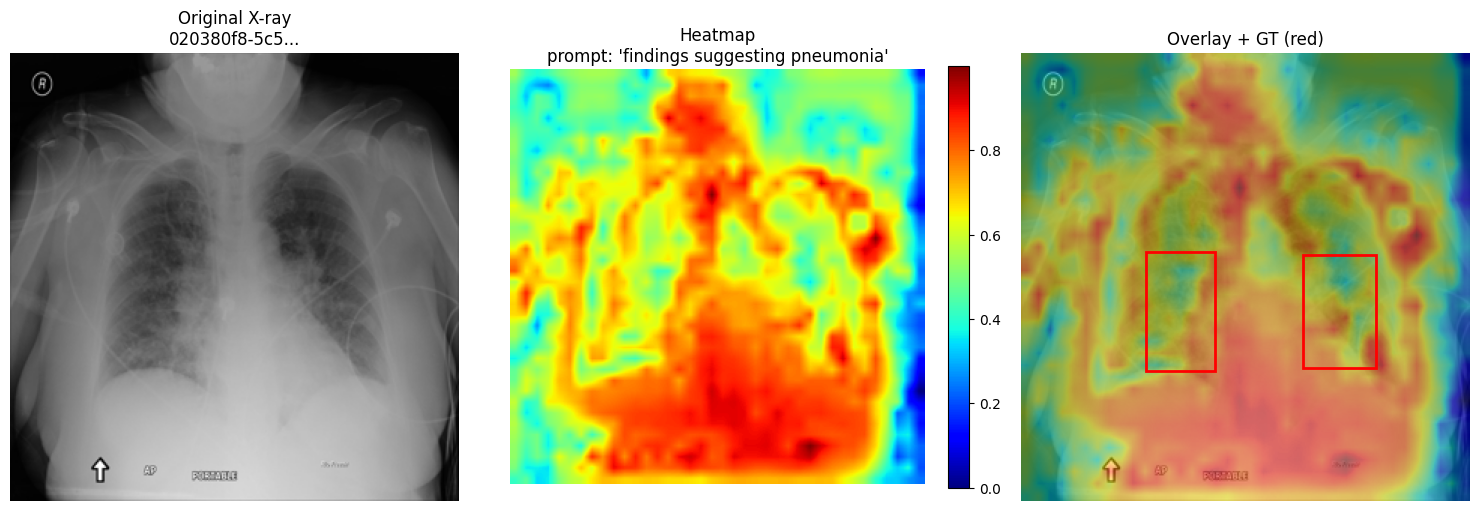

Sim range: [-0.014, 0.204]
GT boxes: [[283.0, 453.0, 157.0, 273.0], [642.0, 460.0, 167.0, 258.0]]

 PHASE 1 COMPLETE: Baseline inference + heatmap works!


In [28]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ========== 1. Load DICOM ==========
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)
image_tensor = transform(image).unsqueeze(0).cuda()

# ========== 2. Tokenize ==========
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
prompt = "findings suggesting pneumonia"
tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                   truncation=True, max_length=128)

x = {
    "imgs": image_tensor,
    "caption_ids": tokens["input_ids"].cuda(),
    "attention_mask": tokens["attention_mask"].cuda(),
    "token_type_ids": tokens["token_type_ids"].cuda(),
}

# ========== 3. Run model ==========
model.eval()
with torch.no_grad():
    res = model(x)

# ========== 4. Extract deep local features (KEY FIX: img_emb_l2) ==========
img_feat = res["img_emb_l2"][0]      # (768, 38, 38)
D, H, W = img_feat.shape
print(f"Deep local feature shape: {img_feat.shape}")

img_flat = img_feat.reshape(D, -1).T                    # (1444, 768)
img_flat = img_flat / (img_flat.norm(dim=-1, keepdim=True) + 1e-8)

txt_feat = res["text_emb_s"].mean(dim=-1).squeeze(0)    # (768,)
txt_feat = txt_feat / (txt_feat.norm() + 1e-8)

# ========== 5. Similarity map ==========
sim = (img_flat @ txt_feat).cpu().numpy()
sim_map = sim.reshape(H, W)

sim_tensor = torch.tensor(sim_map).unsqueeze(0).unsqueeze(0).float()
sim_up = F.interpolate(sim_tensor, size=(299, 299), mode='bilinear', align_corners=False)
sim_up = sim_up.squeeze().numpy()
sim_norm = (sim_up - sim_up.min()) / (sim_up.max() - sim_up.min() + 1e-8)

# ========== 6. Visualize ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image.resize((299, 299)))
axes[0].set_title(f"Original X-ray\n{sample_id[:12]}...")
axes[0].axis('off')

im = axes[1].imshow(sim_norm, cmap='jet')
axes[1].set_title(f"Heatmap\nprompt: '{prompt}'")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(image.resize((299, 299)))
axes[2].imshow(sim_norm, cmap='jet', alpha=0.5)
axes[2].set_title("Overlay + GT (red)")
axes[2].axis('off')

gt_boxes = sampled_df[sampled_df.patientId == sample_id][['x', 'y', 'width', 'height']].values
scale = 299 / 1024
for box in gt_boxes:
    xx, yy, ww, hh = box * scale
    rect = patches.Rectangle((xx, yy), ww, hh, linewidth=2, edgecolor='red', facecolor='none')
    axes[2].add_patch(rect)

plt.tight_layout()
plt.savefig("./first_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"Sim range: [{sim_map.min():.3f}, {sim_map.max():.3f}]")
print(f"GT boxes: {gt_boxes.tolist()}")
print("\n PHASE 1 COMPLETE: Baseline inference + heatmap works!")

# phase-2: robustness stress-test

                                                         prompt category    iou
                                                      pneumonia        N 0.0312
                                  findings suggesting pneumonia        N 0.0116
                                          evidence of pneumonia        N 0.0670
                                      left lower lobe pneumonia       NL 0.0726
                                     right upper lobe pneumonia       NL 0.0365
                                              basilar pneumonia       NL 0.0319
                                               patchy pneumonia       NS 0.0292
                                                focal pneumonia       NS 0.0299
                    patchy consolidation in the left lower lobe      NSL 0.0759
focal opacity in the right upper lobe consistent with pneumonia      NSL 0.0099

=== PROMPT ROBUSTNESS STATS ===
Mean IoU: 0.0396
Std IoU:  0.0240
Min IoU:  0.0099
Max IoU:  0.0759
Range:    0.0660

E

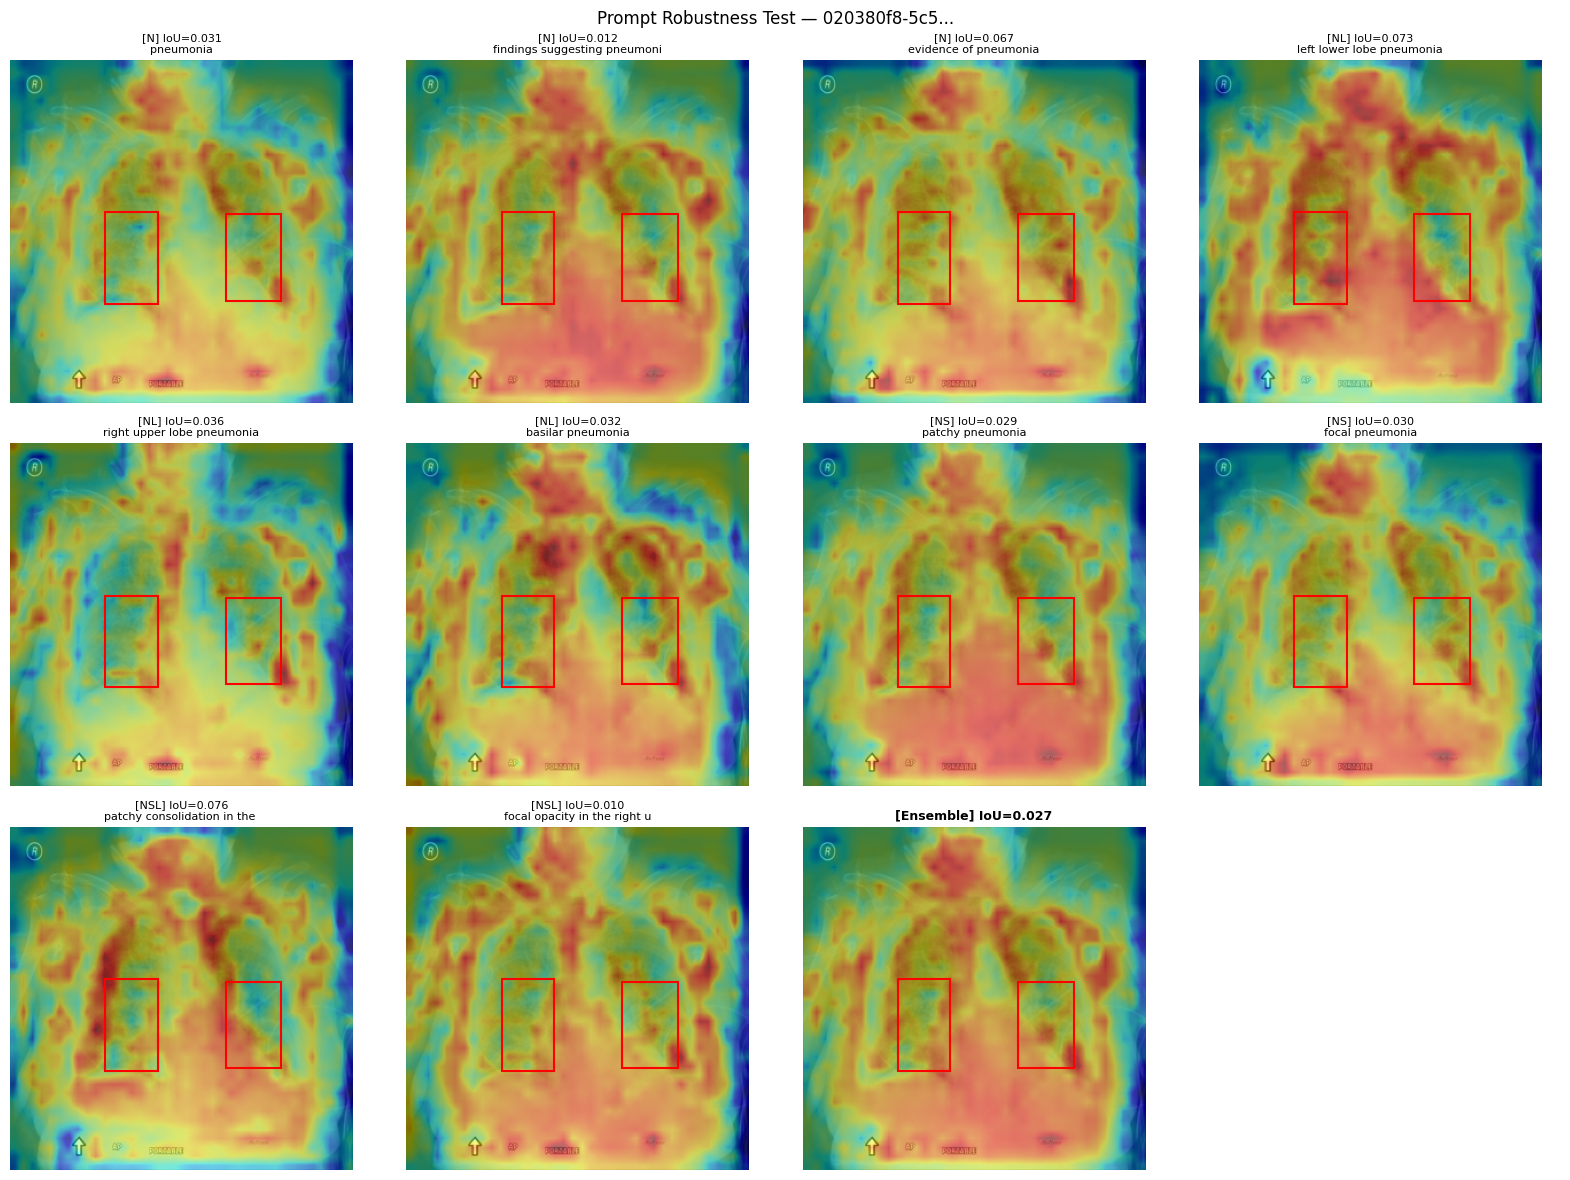


 PHASE 2 (single-image test) COMPLETE


In [29]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# ========== Setup ==========
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

# 10 prompts based on DescriptorMedSAM taxonomy
PROMPTS = [
    {"text": "pneumonia", "category": "N"},
    {"text": "findings suggesting pneumonia", "category": "N"},
    {"text": "evidence of pneumonia", "category": "N"},
    {"text": "left lower lobe pneumonia", "category": "NL"},
    {"text": "right upper lobe pneumonia", "category": "NL"},
    {"text": "basilar pneumonia", "category": "NL"},
    {"text": "patchy pneumonia", "category": "NS"},
    {"text": "focal pneumonia", "category": "NS"},
    {"text": "patchy consolidation in the left lower lobe", "category": "NSL"},
    {"text": "focal opacity in the right upper lobe consistent with pneumonia", "category": "NSL"},
]

# ========== Inference function ==========
def get_heatmap(image, prompt, model, tokenizer, img_size=299):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img_tensor = transform(image).unsqueeze(0).cuda()

    tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                       truncation=True, max_length=128)
    x = {
        "imgs": img_tensor,
        "caption_ids": tokens["input_ids"].cuda(),
        "attention_mask": tokens["attention_mask"].cuda(),
        "token_type_ids": tokens["token_type_ids"].cuda(),
    }

    model.eval()
    with torch.no_grad():
        res = model(x)

    img_feat = res["img_emb_l2"][0]                # (768, H, W)
    D, H, W = img_feat.shape
    img_flat = img_feat.reshape(D, -1).T
    img_flat = img_flat / (img_flat.norm(dim=-1, keepdim=True) + 1e-8)

    # Masked average of sentence features (ignore padding)
    txt_emb = res["text_emb_s"]                    # (1, 768, 128)
    mask = tokens["attention_mask"].float().cuda() # (1, 128)
    mask = mask / (mask.sum(dim=-1, keepdim=True) + 1e-8)
    txt_feat = (txt_emb * mask.unsqueeze(1)).sum(dim=-1).squeeze(0)  # (768,)
    txt_feat = txt_feat / (txt_feat.norm() + 1e-8)

    sim = (img_flat @ txt_feat).cpu().numpy().reshape(H, W)
    sim_t = torch.tensor(sim).unsqueeze(0).unsqueeze(0).float()
    sim_up = F.interpolate(sim_t, size=(img_size, img_size),
                           mode='bilinear', align_corners=False).squeeze().numpy()
    sim_norm = (sim_up - sim_up.min()) / (sim_up.max() - sim_up.min() + 1e-8)
    return sim_norm

# ========== IoU function ==========
def compute_iou(heatmap, gt_boxes, original_size=1024, threshold_pct=80):
    thresh = np.percentile(heatmap, threshold_pct)
    pred_mask = (heatmap >= thresh).astype(np.uint8)
    gt_mask = np.zeros_like(pred_mask)
    scale = 299 / original_size
    for box in gt_boxes:
        x, y, w, h = box * scale
        x1, y1 = int(max(0, x)), int(max(0, y))
        x2, y2 = int(min(299, x + w)), int(min(299, y + h))
        gt_mask[y1:y2, x1:x2] = 1
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    return inter / (union + 1e-8)

# ========== Run all prompts on the sample image ==========
sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)
gt_boxes = sampled_df[sampled_df.patientId == sample_id][['x', 'y', 'width', 'height']].values

results, heatmaps = [], []
for p in PROMPTS:
    hm = get_heatmap(image, p["text"], model, tokenizer)
    iou = compute_iou(hm, gt_boxes)
    results.append({"prompt": p["text"], "category": p["category"], "iou": round(iou, 4)})
    heatmaps.append(hm)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print(f"\n=== PROMPT ROBUSTNESS STATS ===")
print(f"Mean IoU: {df_results['iou'].mean():.4f}")
print(f"Std IoU:  {df_results['iou'].std():.4f}")
print(f"Min IoU:  {df_results['iou'].min():.4f}")
print(f"Max IoU:  {df_results['iou'].max():.4f}")
print(f"Range:    {df_results['iou'].max() - df_results['iou'].min():.4f}")

# ========== Ensemble ==========
ensemble_hm = np.mean(heatmaps, axis=0)
ensemble_iou = compute_iou(ensemble_hm, gt_boxes)
print(f"\nEnsemble IoU: {ensemble_iou:.4f}")
print(f"Best single:  {df_results['iou'].max():.4f}")
print(f"Worst single: {df_results['iou'].min():.4f}")

# ========== Visualize ==========
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
scale = 299 / 1024

for i, (p, hm, iou) in enumerate(zip(PROMPTS, heatmaps, df_results['iou'])):
    axes[i].imshow(image.resize((299, 299)), cmap='gray')
    axes[i].imshow(hm, cmap='jet', alpha=0.5)
    for box in gt_boxes:
        x, y, w, h = box * scale
        axes[i].add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                                             edgecolor='red', facecolor='none'))
    axes[i].set_title(f"[{p['category']}] IoU={iou:.3f}\n{p['text'][:28]}", fontsize=8)
    axes[i].axis('off')

# Ensemble panel
axes[10].imshow(image.resize((299, 299)), cmap='gray')
axes[10].imshow(ensemble_hm, cmap='jet', alpha=0.5)
for box in gt_boxes:
    x, y, w, h = box * scale
    axes[10].add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                                         edgecolor='red', facecolor='none'))
axes[10].set_title(f"[Ensemble] IoU={ensemble_iou:.3f}", fontsize=9, fontweight='bold')
axes[10].axis('off')
axes[11].axis('off')

plt.suptitle(f"Prompt Robustness Test — {sample_id[:12]}...", fontsize=12)
plt.tight_layout()
plt.savefig("./phase2_robustness.png", dpi=100, bbox_inches='tight')
plt.show()

print("\n PHASE 2 (single-image test) COMPLETE")

In [30]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer
import pandas as pd

DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

# Use the best prompt from your first run
BEST_PROMPT = "patchy consolidation in the left lower lobe"

# Setup
sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)
gt_boxes = sampled_df[sampled_df.patientId == sample_id][['x', 'y', 'width', 'height']].values

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(image).unsqueeze(0).cuda()

tokens = tokenizer(BEST_PROMPT, return_tensors="pt", padding="max_length",
                   truncation=True, max_length=128)
x = {
    "imgs": img_tensor,
    "caption_ids": tokens["input_ids"].cuda(),
    "attention_mask": tokens["attention_mask"].cuda(),
    "token_type_ids": tokens["token_type_ids"].cuda(),
}

with torch.no_grad():
    res = model(x)

img_feat = res["img_emb_l2"][0]
D, H, W = img_feat.shape
img_flat = img_feat.reshape(D, -1).T
img_flat = img_flat / (img_flat.norm(dim=-1, keepdim=True) + 1e-8)

# --- METHOD A: masked average (what we did before) ---
mask = tokens["attention_mask"].float().cuda()
mask_n = mask / (mask.sum(dim=-1, keepdim=True) + 1e-8)
txt_A = (res["text_emb_s"] * mask_n.unsqueeze(1)).sum(dim=-1).squeeze(0)
txt_A = txt_A / (txt_A.norm() + 1e-8)

# --- METHOD B: only content words (skip CLS, SEP, PAD, UNK) ---
# Get token IDs for the actual words (skip special tokens)
input_ids = tokens["input_ids"][0]
special = {tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id}
content_mask = torch.tensor([i.item() not in special for i in input_ids]).cuda()
if content_mask.sum() == 0:
    content_mask = mask[0].bool()
content_positions = content_mask.nonzero(as_tuple=True)[0]

txt_emb_all = res["text_emb_s"][0]  # (768, 128)
txt_B = txt_emb_all[:, content_positions].mean(dim=-1)
txt_B = txt_B / (txt_B.norm() + 1e-8)

# --- Compute heatmaps for both methods ---
def make_heatmap(txt_vec):
    sim = (img_flat @ txt_vec).cpu().numpy().reshape(H, W)
    sim_t = torch.tensor(sim).unsqueeze(0).unsqueeze(0).float()
    up = F.interpolate(sim_t, size=(299, 299), mode='bilinear', align_corners=False).squeeze().numpy()
    return (up - up.min()) / (up.max() - up.min() + 1e-8)

hm_A = make_heatmap(txt_A)
hm_B = make_heatmap(txt_B)

# --- Compute IoU at multiple thresholds ---
def iou_at(heatmap, gt_boxes, thresh):
    pred = (heatmap >= thresh).astype(np.uint8)
    gt_mask = np.zeros_like(pred)
    scale = 299 / 1024
    for box in gt_boxes:
        xx, yy, ww, hh = box * scale
        x1, y1 = int(max(0, xx)), int(max(0, yy))
        x2, y2 = int(min(299, xx + ww)), int(min(299, yy + hh))
        gt_mask[y1:y2, x1:x2] = 1
    inter = np.logical_and(pred, gt_mask).sum()
    union = np.logical_or(pred, gt_mask).sum()
    return inter / (union + 1e-8)

# GT box area
gt_mask = np.zeros((299, 299))
scale = 299 / 1024
for box in gt_boxes:
    xx, yy, ww, hh = box * scale
    x1, y1 = int(max(0, xx)), int(max(0, yy))
    x2, y2 = int(min(299, xx + ww)), int(min(299, yy + hh))
    gt_mask[y1:y2, x1:x2] = 1
gt_area_pct = 100 * gt_mask.sum() / (299 * 299)
print(f"GT box area: {gt_area_pct:.2f}% of image")
print(f"GT boxes: {gt_boxes.tolist()}\n")

print(f"{'Threshold':>10} | {'IoU (masked avg)':>16} | {'IoU (content only)':>18}")
print("-" * 52)
for t in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]:
    print(f"{t:>10.2f} | {iou_at(hm_A, gt_boxes, t):>16.4f} | {iou_at(hm_B, gt_boxes, t):>18.4f}")

print(f"\nPrompt: '{BEST_PROMPT}'")

GT box area: 8.18% of image
GT boxes: [[283.0, 453.0, 157.0, 273.0], [642.0, 460.0, 167.0, 258.0]]

 Threshold | IoU (masked avg) | IoU (content only)
----------------------------------------------------
      0.50 |           0.0868 |             0.0785
      0.60 |           0.0877 |             0.0806
      0.70 |           0.0794 |             0.0837
      0.80 |           0.0849 |             0.0895
      0.85 |           0.0281 |             0.0770
      0.90 |           0.0091 |             0.0314
      0.95 |           0.0016 |             0.0074

Prompt: 'patchy consolidation in the left lower lobe'


# Diagnostic 1: Try Word-Level and Global Features

In [31]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms

DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)
gt_boxes = sampled_df[sampled_df.patientId == sample_id][['x', 'y', 'width', 'height']].values

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(image).unsqueeze(0).cuda()

prompt = "patchy consolidation in the left lower lobe"
tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                   truncation=True, max_length=128)
x = {"imgs": img_tensor,
     "caption_ids": tokens["input_ids"].cuda(),
     "attention_mask": tokens["attention_mask"].cuda(),
     "token_type_ids": tokens["token_type_ids"].cuda()}

model.eval()
with torch.no_grad():
    res = model(x)

# ---------- Print ALL keys and shapes to see what's available ----------
print("=== AVAILABLE KEYS IN `res` ===")
for k, v in res.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")
    else:
        print(f"  {k}: {type(v).__name__}")
print()

# ---------- Dynamically pick image features ----------
image_keys = [k for k in res.keys() if k.startswith("img_emb") and torch.is_tensor(res[k]) and res[k].dim() == 4]
text_keys  = [k for k in res.keys() if k.startswith("text") and torch.is_tensor(res[k])]

print(f"Image feature keys (4D): {image_keys}")
print(f"Text feature keys:       {text_keys}")
print()

mask = tokens["attention_mask"].float().cuda()
mask_n = mask / (mask.sum(dim=-1, keepdim=True) + 1e-8)

def build_heatmap(img_feat, txt_emb):
    D, H, W = img_feat.shape
    flat = img_feat.reshape(D, -1).T
    flat = flat / (flat.norm(dim=-1, keepdim=True) + 1e-8)
    txt = (txt_emb * mask_n.unsqueeze(1)).sum(dim=-1).squeeze(0)
    txt = txt / (txt.norm() + 1e-8)
    sim = (flat @ txt).cpu().numpy().reshape(H, W)
    sim_t = torch.tensor(sim).unsqueeze(0).unsqueeze(0).float()
    up = F.interpolate(sim_t, size=(299, 299), mode='bilinear', align_corners=False).squeeze().numpy()
    return (up - up.min()) / (up.max() - up.min() + 1e-8)

def iou_top(heatmap, gt_boxes, top_pct):
    thresh = np.percentile(heatmap, 100 - top_pct)
    pred = (heatmap >= thresh)
    gt_mask = np.zeros((299, 299), dtype=bool)
    scale = 299 / 1024
    for box in gt_boxes:
        xx, yy, ww, hh = box * scale
        x1, y1 = int(max(0, xx)), int(max(0, yy))
        x2, y2 = int(min(299, xx + ww)), int(min(299, yy + hh))
        gt_mask[y1:y2, x1:x2] = True
    return (pred & gt_mask).sum() / ((pred | gt_mask).sum() + 1e-8)

# ---------- Grid over ALL available image × text features ----------
print(f"{'Image Feat':>14} | {'Text Feat':>12} | {'Top-5%':>8} | {'Top-10%':>8} | {'Top-20%':>8} | {'Top-30%':>8}")
print("-" * 82)
for img_key in image_keys:
    img_f = res[img_key][0]
    for txt_key in text_keys:
        if res[txt_key].dim() != 3:  # skip report-level (2D)
            continue
        hm = build_heatmap(img_f, res[txt_key])
        row = f"{img_key:>14} | {txt_key:>12} |"
        for pct in [5, 10, 20, 30]:
            row += f" {iou_top(hm, gt_boxes, pct):>8.4f} |"
        print(row)

=== AVAILABLE KEYS IN `res` ===
  img_emb_l: (1, 768, 19, 19)
  img_emb_l2: (1, 768, 38, 38)
  img_emb_lf: NoneType
  img_emb_g: (1, 768)
  text_emb_w: (1, 768, 128)
  text_emb_r: (1, 768)
  text_emb_s: (1, 768, 128)
  report: list
  sent_units_report: list

Image feature keys (4D): ['img_emb_l', 'img_emb_l2']
Text feature keys:       ['text_emb_w', 'text_emb_r', 'text_emb_s']

    Image Feat |    Text Feat |   Top-5% |  Top-10% |  Top-20% |  Top-30%
----------------------------------------------------------------------------------
     img_emb_l |   text_emb_w |   0.0406 |   0.0632 |   0.0726 |   0.0923 |
     img_emb_l |   text_emb_s |   0.0115 |   0.0433 |   0.0518 |   0.0710 |
    img_emb_l2 |   text_emb_w |   0.0930 |   0.0972 |   0.0845 |   0.0804 |
    img_emb_l2 |   text_emb_s |   0.0642 |   0.0883 |   0.0759 |   0.0819 |


# Diagnostic 2: Check If the Model Is Even Working Correctly

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9342489..2.6609476].


=== HEATMAP STATS ===
Real image  — range: [0.000, 1.000]  mean: 0.596
Noise image — range: [0.000, 1.000]  mean: 0.662
Black image — range: [0.000, 1.000]  mean: 0.477

=== CORRELATION MATRIX ===
Real  vs Noise:  0.3143
Real  vs Black:  0.3385
Noise vs Black:  0.2702

=== INTERPRETATION ===
  MODERATE correlation → partial image dependence.


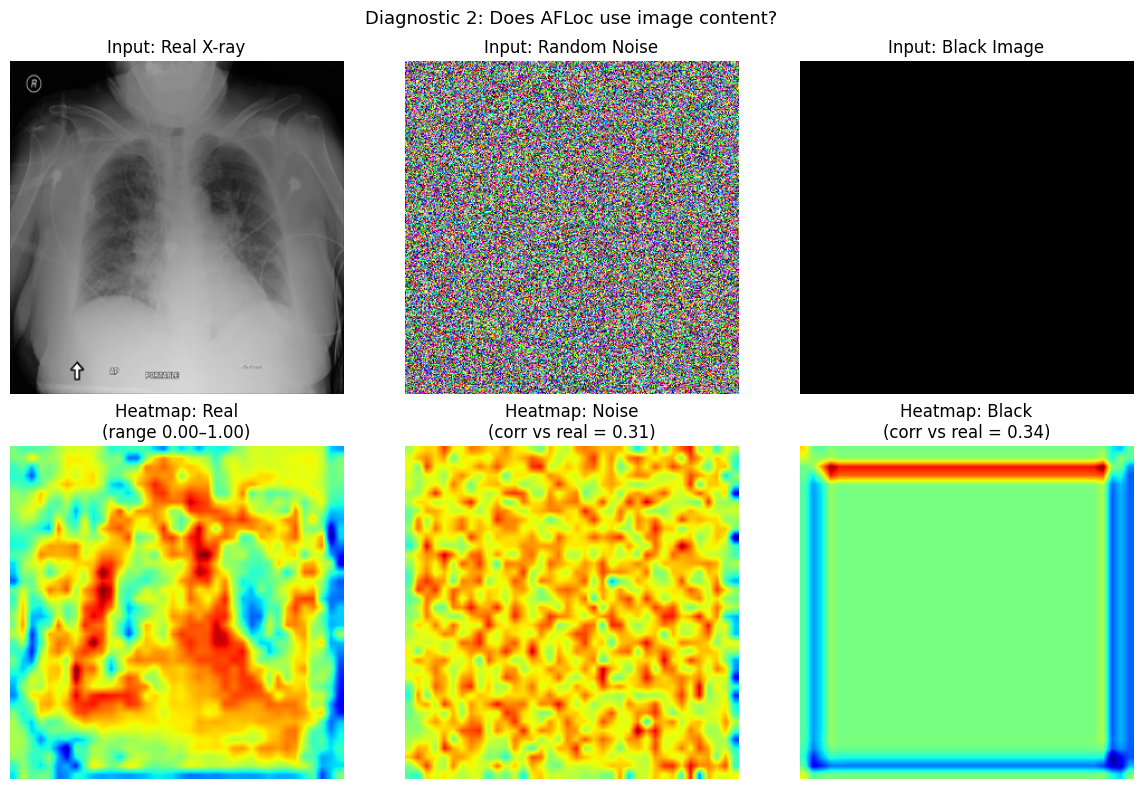


Diagnostic 2 complete.


In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms

# ========== Setup ==========
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

sample_id = sampled_df.iloc[0]['patientId']
image = load_dicom(sample_id)

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(image).unsqueeze(0).cuda()

prompt = "patchy consolidation in the left lower lobe"
tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                   truncation=True, max_length=128)

mask = tokens["attention_mask"].float().cuda()
mask_n = mask / (mask.sum(dim=-1, keepdim=True) + 1e-8)

def get_heatmap(img_tensor, tokens, model, mask_n):
    x = {"imgs": img_tensor,
         "caption_ids": tokens["input_ids"].cuda(),
         "attention_mask": tokens["attention_mask"].cuda(),
         "token_type_ids": tokens["token_type_ids"].cuda()}
    model.eval()
    with torch.no_grad():
        res = model(x)
    feat = res["img_emb_l2"][0]              # (768, 38, 38)
    D, H, W = feat.shape
    flat = feat.reshape(D, -1).T
    flat = flat / (flat.norm(dim=-1, keepdim=True) + 1e-8)
    # Use word-level text (best from diagnostic 1)
    txt = (res["text_emb_w"] * mask_n.unsqueeze(1)).sum(dim=-1).squeeze(0)
    txt = txt / (txt.norm() + 1e-8)
    sim = (flat @ txt).cpu().numpy().reshape(H, W)
    sim_t = torch.tensor(sim).unsqueeze(0).unsqueeze(0).float()
    up = F.interpolate(sim_t, size=(299, 299), mode='bilinear',
                       align_corners=False).squeeze().numpy()
    return (up - up.min()) / (up.max() - up.min() + 1e-8)

# ========== THREE INPUTS: real, noise, black ==========
hm_real  = get_heatmap(img_tensor, tokens, model, mask_n)

noise = torch.randn_like(img_tensor).cuda()
hm_noise = get_heatmap(noise, tokens, model, mask_n)

black = torch.zeros_like(img_tensor).cuda()
hm_black = get_heatmap(black, tokens, model, mask_n)

# ========== Correlations ==========
c_real_noise = np.corrcoef(hm_real.flatten(), hm_noise.flatten())[0, 1]
c_real_black = np.corrcoef(hm_real.flatten(), hm_black.flatten())[0, 1]
c_noise_black = np.corrcoef(hm_noise.flatten(), hm_black.flatten())[0, 1]

print("=== HEATMAP STATS ===")
print(f"Real image  — range: [{hm_real.min():.3f}, {hm_real.max():.3f}]  mean: {hm_real.mean():.3f}")
print(f"Noise image — range: [{hm_noise.min():.3f}, {hm_noise.max():.3f}]  mean: {hm_noise.mean():.3f}")
print(f"Black image — range: [{hm_black.min():.3f}, {hm_black.max():.3f}]  mean: {hm_black.mean():.3f}")
print()
print("=== CORRELATION MATRIX ===")
print(f"Real  vs Noise: {c_real_noise:>7.4f}")
print(f"Real  vs Black: {c_real_black:>7.4f}")
print(f"Noise vs Black: {c_noise_black:>7.4f}")
print()
print("=== INTERPRETATION ===")
if c_real_noise < 0.3 and c_real_black < 0.3:
    print(" Model IS using image content. Real image is distinct from noise/black.")
elif c_real_noise > 0.5 or c_real_black > 0.5:
    print("  HIGH correlation → model output is dominated by a learned prior.")
    print("   Model not truly using image-specific content.")
else:
    print("  MODERATE correlation → partial image dependence.")

# ========== Visualize ==========
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(image.resize((299, 299)))
axes[0, 0].set_title("Input: Real X-ray")
axes[0, 0].axis('off')

axes[0, 1].imshow(noise[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
axes[0, 1].set_title("Input: Random Noise")
axes[0, 1].axis('off')

axes[0, 2].imshow(black[0].permute(1, 2, 0).cpu().numpy())
axes[0, 2].set_title("Input: Black Image")
axes[0, 2].axis('off')

axes[1, 0].imshow(hm_real, cmap='jet')
axes[1, 0].set_title(f"Heatmap: Real\n(range {hm_real.min():.2f}–{hm_real.max():.2f})")
axes[1, 0].axis('off')

axes[1, 1].imshow(hm_noise, cmap='jet')
axes[1, 1].set_title(f"Heatmap: Noise\n(corr vs real = {c_real_noise:.2f})")
axes[1, 1].axis('off')

axes[1, 2].imshow(hm_black, cmap='jet')
axes[1, 2].set_title(f"Heatmap: Black\n(corr vs real = {c_real_black:.2f})")
axes[1, 2].axis('off')

plt.suptitle("Diagnostic 2: Does AFLoc use image content?", fontsize=13)
plt.tight_layout()
plt.savefig("./diagnostic2.png", dpi=100, bbox_inches='tight')
plt.show()

print("\nDiagnostic 2 complete.")

In [33]:
import torch
import torch.nn.functional as F
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
import pandas as pd
import os
from tqdm import tqdm

# ========== Config ==========
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
OUTPUT_DIR = "/kaggle/working/afloc_r_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_IMAGES = 200                # use all 200
IMG_SIZE = 299
ORIG_SIZE = 1024

PROMPTS = [
    {"text": "pneumonia", "category": "N"},
    {"text": "findings suggesting pneumonia", "category": "N"},
    {"text": "evidence of pneumonia", "category": "N"},
    {"text": "left lower lobe pneumonia", "category": "NL"},
    {"text": "right upper lobe pneumonia", "category": "NL"},
    {"text": "basilar pneumonia", "category": "NL"},
    {"text": "patchy pneumonia", "category": "NS"},
    {"text": "focal pneumonia", "category": "NS"},
    {"text": "patchy consolidation in the left lower lobe", "category": "NSL"},
    {"text": "focal opacity in the right upper lobe consistent with pneumonia", "category": "NSL"},
]

# ========== Helpers ==========
def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def build_gt_mask(gt_boxes, size=IMG_SIZE, orig=ORIG_SIZE):
    gt = np.zeros((size, size), dtype=bool)
    scale = size / orig
    for box in gt_boxes:
        x, y, w, h = box * scale
        x1, y1 = int(max(0, x)), int(max(0, y))
        x2, y2 = int(min(size, x + w)), int(min(size, y + h))
        gt[y1:y2, x1:x2] = True
    return gt

def compute_heatmap_and_iou(image, prompt, gt_mask):
    img_tensor = transform(image).unsqueeze(0).cuda()
    tokens = tokenizer(prompt, return_tensors="pt", padding="max_length",
                       truncation=True, max_length=128)
    x = {"imgs": img_tensor,
         "caption_ids": tokens["input_ids"].cuda(),
         "attention_mask": tokens["attention_mask"].cuda(),
         "token_type_ids": tokens["token_type_ids"].cuda()}

    model.eval()
    with torch.no_grad():
        res = model(x)

    feat = res["img_emb_l2"][0]  # (768, 38, 38)
    D, H, W = feat.shape
    flat = feat.reshape(D, -1).T
    flat = flat / (flat.norm(dim=-1, keepdim=True) + 1e-8)

    mask = tokens["attention_mask"].float().cuda()
    mask_n = mask / (mask.sum(dim=-1, keepdim=True) + 1e-8)
    txt = (res["text_emb_w"] * mask_n.unsqueeze(1)).sum(dim=-1).squeeze(0)
    txt = txt / (txt.norm() + 1e-8)

    sim = (flat @ txt).cpu().numpy().reshape(H, W)
    sim_t = torch.tensor(sim).unsqueeze(0).unsqueeze(0).float()
    up = F.interpolate(sim_t, size=(IMG_SIZE, IMG_SIZE), mode='bilinear',
                       align_corners=False).squeeze().numpy()
    hm = (up - up.min()) / (up.max() - up.min() + 1e-8)

    # Top-5% thresholding (best from Diagnostic 1)
    thresh = np.percentile(hm, 95)
    pred = (hm >= thresh)
    inter = (pred & gt_mask).sum()
    union = (pred | gt_mask).sum()
    iou = inter / (union + 1e-8)
    return hm, iou

# ========== Main Loop ==========
unique_patients = sampled_df['patientId'].unique()[:N_IMAGES]
results = []

# ---- Checkpoint: resume if partial results exist ----
partial_csv = os.path.join(OUTPUT_DIR, "iou_results.csv")
processed = set()
if os.path.exists(partial_csv):
    existing = pd.read_csv(partial_csv)
    processed = set(existing['patientId'].unique())
    results = existing.to_dict('records')
    print(f"Resuming from {len(processed)} already-processed images.")

remaining = [p for p in unique_patients if p not in processed]
print(f"Processing {len(remaining)} images × {len(PROMPTS)} prompts = {len(remaining)*len(PROMPTS)} inferences.")

for i, pid in enumerate(tqdm(remaining, desc="Images")):
    image = load_dicom(pid)
    gt_boxes = sampled_df[sampled_df.patientId == pid][['x', 'y', 'width', 'height']].values
    gt_mask = build_gt_mask(gt_boxes)

    for p in PROMPTS:
        hm, iou = compute_heatmap_and_iou(image, p["text"], gt_mask)
        results.append({
            "patientId": pid,
            "prompt": p["text"],
            "category": p["category"],
            "iou": float(iou),
        })

    # ---- Save every 10 images (checkpoint) ----
    if i % 10 == 9:
        pd.DataFrame(results).to_csv(partial_csv, index=False)

# ---- Final save ----
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(OUTPUT_DIR, "iou_results.csv"), index=False)
print(f"\n✅ Saved {len(df_results)} results to {partial_csv}")

# ========== Summary Statistics ==========
print("\n=== PER-PROMPT PERFORMANCE ===")
summary = df_results.groupby(['category', 'prompt'])['iou'].agg(['mean', 'std', 'count'])
summary = summary.sort_values('mean', ascending=False)
print(summary)

print("\n=== PER-CATEGORY PERFORMANCE ===")
cat_summary = df_results.groupby('category')['iou'].agg(['mean', 'std', 'count'])
print(cat_summary)

print("\n=== PER-IMAGE VARIANCE (prompt sensitivity) ===")
per_image = df_results.groupby('patientId')['iou'].agg(['mean', 'std', 'min', 'max'])
per_image['range'] = per_image['max'] - per_image['min']
print(f"Mean per-image IoU:       {per_image['mean'].mean():.4f}")
print(f"Mean per-image std:       {per_image['std'].mean():.4f}")
print(f"Mean per-image range:     {per_image['range'].mean():.4f}")
print(f"Overall prompt-stability: {df_results['iou'].std():.4f}")

print("\n=== ENSEMBLE TEST ===")
# For each image, compute ensemble heatmap = mean of all prompts
ensemble_ious = []
for pid in tqdm(unique_patients[:N_IMAGES], desc="Ensemble"):
    image = load_dicom(pid)
    gt_boxes = sampled_df[sampled_df.patientId == pid][['x', 'y', 'width', 'height']].values
    gt_mask = build_gt_mask(gt_boxes)

    hms = []
    for p in PROMPTS:
        hm, _ = compute_heatmap_and_iou(image, p["text"], gt_mask)
        hms.append(hm)
    ens = np.mean(hms, axis=0)
    thresh = np.percentile(ens, 95)
    pred = (ens >= thresh)
    inter = (pred & gt_mask).sum()
    union = (pred | gt_mask).sum()
    ensemble_ious.append(inter / (union + 1e-8))

df_results.to_csv(os.path.join(OUTPUT_DIR, "iou_results.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "ensemble_results.txt"), "w") as f:
    f.write(f"Ensemble mean IoU: {np.mean(ensemble_ious):.4f}\n")
    f.write(f"Ensemble std IoU:  {np.std(ensemble_ious):.4f}\n")
    f.write(f"Best single mean:  {df_results.groupby('patientId')['iou'].max().mean():.4f}\n")
    f.write(f"Worst single mean: {df_results.groupby('patientId')['iou'].min().mean():.4f}\n")

print(f"\nEnsemble mean IoU: {np.mean(ensemble_ious):.4f}")
print(f"Best single mean:  {df_results.groupby('patientId')['iou'].max().mean():.4f}")
print(f"Worst single mean: {df_results.groupby('patientId')['iou'].min().mean():.4f}")
print(f"\n PHASE 2 COMPLETE")

Processing 200 images × 10 prompts = 2000 inferences.


Images: 100%|██████████| 200/200 [01:04<00:00,  3.10it/s]



✅ Saved 2000 results to /kaggle/working/afloc_r_results/iou_results.csv

=== PER-PROMPT PERFORMANCE ===
                                                                 mean  \
category prompt                                                         
NL       left lower lobe pneumonia                           0.105376   
NSL      patchy consolidation in the left lower lobe         0.099071   
NL       basilar pneumonia                                   0.084133   
N        pneumonia                                           0.070353   
         evidence of pneumonia                               0.067104   
NL       right upper lobe pneumonia                          0.049537   
NS       focal pneumonia                                     0.046402   
         patchy pneumonia                                    0.042307   
NSL      focal opacity in the right upper lobe consisten...  0.029775   
N        findings suggesting pneumonia                       0.025100   

                  

Ensemble: 100%|██████████| 200/200 [01:01<00:00,  3.23it/s]


Ensemble mean IoU: 0.0773
Best single mean:  0.1330
Worst single mean: 0.0130

 PHASE 2 COMPLETE


In [34]:
import pandas as pd
import os

OUTPUT_DIR = "/kaggle/working/afloc_r_results"
df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")
print(f"Rows: {len(df)}")   # Should be 2000
print(f"Columns: {df.columns.tolist()}")
print(f"Unique patients: {df['patientId'].nunique()}")
print(f"Unique prompts: {df['prompt'].nunique()}")

print("\nFiles in output dir:")
for f in os.listdir(OUTPUT_DIR):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f}: {size_kb:.1f} KB")

print("\nFirst 5 rows:")
print(df.head())

Rows: 2000
Columns: ['patientId', 'prompt', 'category', 'iou']
Unique patients: 200
Unique prompts: 10

Files in output dir:
  iou_results.csv: 168.7 KB
  ensemble_results.txt: 0.1 KB

First 5 rows:
                              patientId                         prompt  \
0  020380f8-5c5a-4ded-bdf3-9ce3036945b4                      pneumonia   
1  020380f8-5c5a-4ded-bdf3-9ce3036945b4  findings suggesting pneumonia   
2  020380f8-5c5a-4ded-bdf3-9ce3036945b4          evidence of pneumonia   
3  020380f8-5c5a-4ded-bdf3-9ce3036945b4      left lower lobe pneumonia   
4  020380f8-5c5a-4ded-bdf3-9ce3036945b4     right upper lobe pneumonia   

  category       iou  
0        N  0.013159  
1        N  0.000000  
2        N  0.020532  
3       NL  0.079051  
4       NL  0.013591  


In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/working/afloc_r_results/iou_results.csv")

# Table 1: Per-prompt
t1 = df.groupby(['category', 'prompt'])['iou'].agg(['mean', 'std']).round(4)
t1 = t1.sort_values('mean', ascending=False)
t1.to_csv("/kaggle/working/afloc_r_results/table1_per_prompt.csv")
print("=== TABLE 1: Per-Prompt ===")
print(t1)

# Table 2: Per-category
t2 = df.groupby('category')['iou'].agg(['mean', 'std', 'count']).round(4)
t2.to_csv("/kaggle/working/afloc_r_results/table2_per_category.csv")
print("\n=== TABLE 2: Per-Category ===")
print(t2)

# Table 3: Per-image variance
t3 = df.groupby('patientId')['iou'].agg(['mean', 'std', 'min', 'max'])
t3['range'] = t3['max'] - t3['min']
t3.to_csv("/kaggle/working/afloc_r_results/table3_per_image.csv")
print("\n=== TABLE 3: Summary ===")
print(f"Mean per-image IoU:      {t3['mean'].mean():.4f}")
print(f"Mean per-image std:      {t3['std'].mean():.4f}")
print(f"Mean per-image range:    {t3['range'].mean():.4f}")
print(f"Overall prompt-stability: {df['iou'].std():.4f}")

=== TABLE 1: Per-Prompt ===
                                                               mean     std
category prompt                                                            
NL       left lower lobe pneumonia                           0.1054  0.0627
NSL      patchy consolidation in the left lower lobe         0.0991  0.0528
NL       basilar pneumonia                                   0.0841  0.0563
N        pneumonia                                           0.0704  0.0486
         evidence of pneumonia                               0.0671  0.0447
NL       right upper lobe pneumonia                          0.0495  0.0427
NS       focal pneumonia                                     0.0464  0.0453
         patchy pneumonia                                    0.0423  0.0434
NSL      focal opacity in the right upper lobe consisten...  0.0298  0.0309
N        findings suggesting pneumonia                       0.0251  0.0311

=== TABLE 2: Per-Category ===
            mean     std  cou

# Visualization 1: Per-Prompt IoU Bar Chart

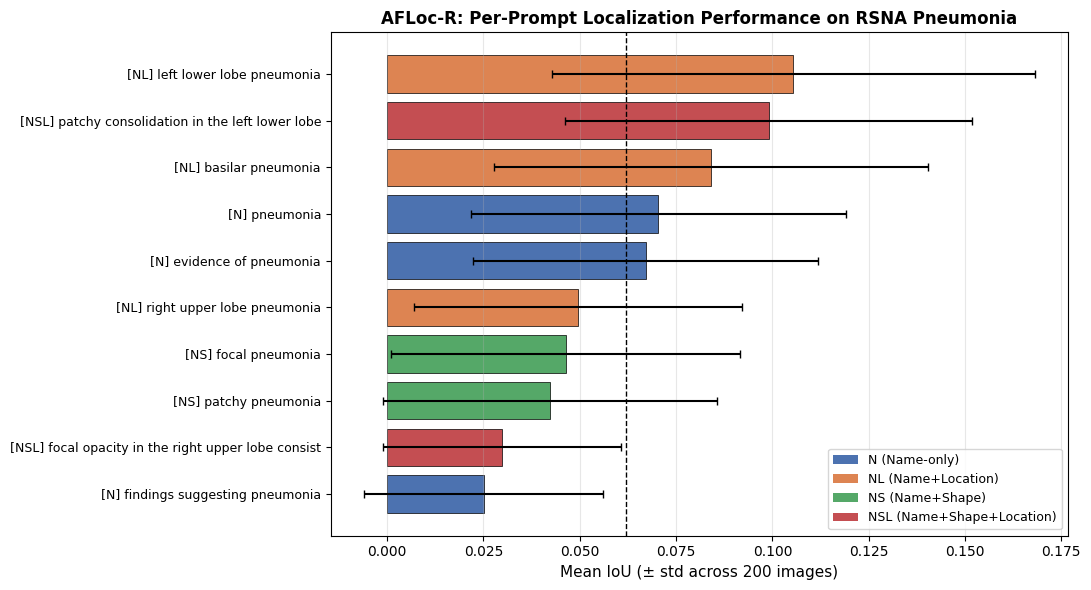

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/afloc_r_results/iou_results.csv")

# Aggregate per-prompt
prompt_stats = df.groupby(['category', 'prompt'])['iou'].agg(['mean', 'std', 'count']).reset_index()
prompt_stats = prompt_stats.sort_values('mean', ascending=True)

# Color by category
colors = {'N': '#4C72B0', 'NL': '#DD8452', 'NS': '#55A868', 'NSL': '#C44E52'}
bar_colors = [colors[c] for c in prompt_stats['category']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(prompt_stats)), prompt_stats['mean'],
               xerr=prompt_stats['std'], color=bar_colors,
               edgecolor='black', linewidth=0.5, capsize=3)

ax.set_yticks(range(len(prompt_stats)))
ax.set_yticklabels([f"[{c}] {p[:45]}" for c, p in zip(prompt_stats['category'], prompt_stats['prompt'])],
                    fontsize=9)
ax.set_xlabel("Mean IoU (± std across 200 images)", fontsize=11)
ax.set_title("AFLoc-R: Per-Prompt Localization Performance on RSNA Pneumonia",
             fontsize=12, fontweight='bold')
ax.axvline(df['iou'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Overall mean = {df['iou'].mean():.4f}")
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Add legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[c], label=f'{c} ({n})')
                   for c, n in [('N', 'Name-only'), ('NL', 'Name+Location'),
                                ('NS', 'Name+Shape'), ('NSL', 'Name+Shape+Location')]]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/afloc_r_results/fig1_per_prompt.png", dpi=150, bbox_inches='tight')
plt.show()

# Visualization 2: Per-Category Box Plot

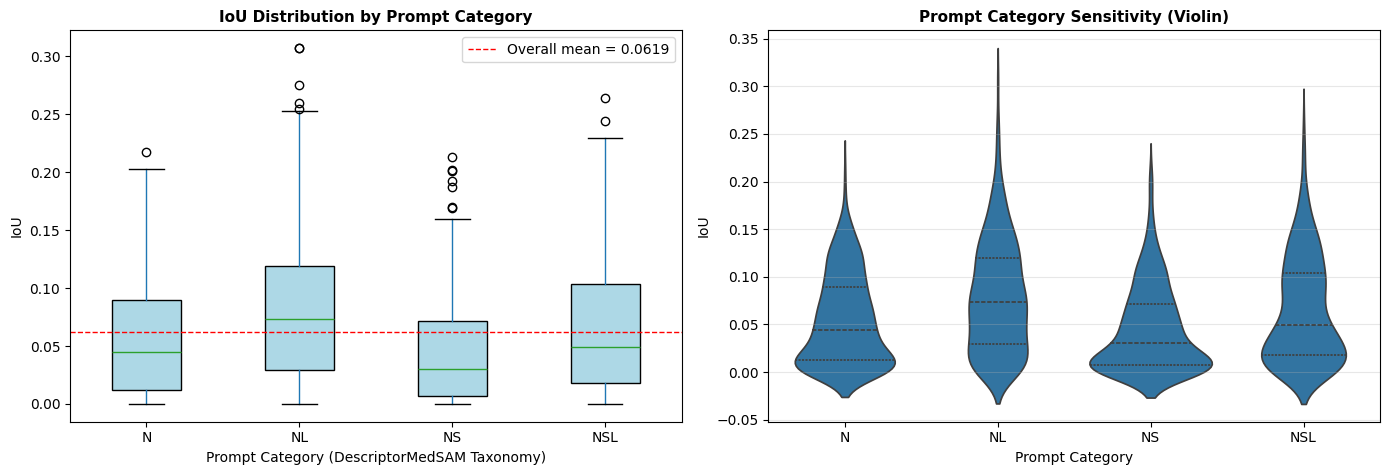

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box plot
df.boxplot(column='iou', by='category', ax=axes[0], grid=False,
           patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0].set_title("IoU Distribution by Prompt Category", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Prompt Category (DescriptorMedSAM Taxonomy)")
axes[0].set_ylabel("IoU")
axes[0].axhline(df['iou'].mean(), color='red', linestyle='--', linewidth=1,
                label=f"Overall mean = {df['iou'].mean():.4f}")
axes[0].legend()
plt.sca(axes[0])
plt.title("IoU Distribution by Prompt Category", fontsize=11, fontweight='bold')

# Right: violin plot
import seaborn as sns
sns.violinplot(data=df, x='category', y='iou', ax=axes[1], inner='quartile')
axes[1].set_title("Prompt Category Sensitivity (Violin)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Prompt Category")
axes[1].set_ylabel("IoU")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("")  # remove pandas default
plt.tight_layout()
plt.savefig("/kaggle/working/afloc_r_results/fig2_category_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Visualization 3: Per-Image Variance (Prompt Sensitivity)

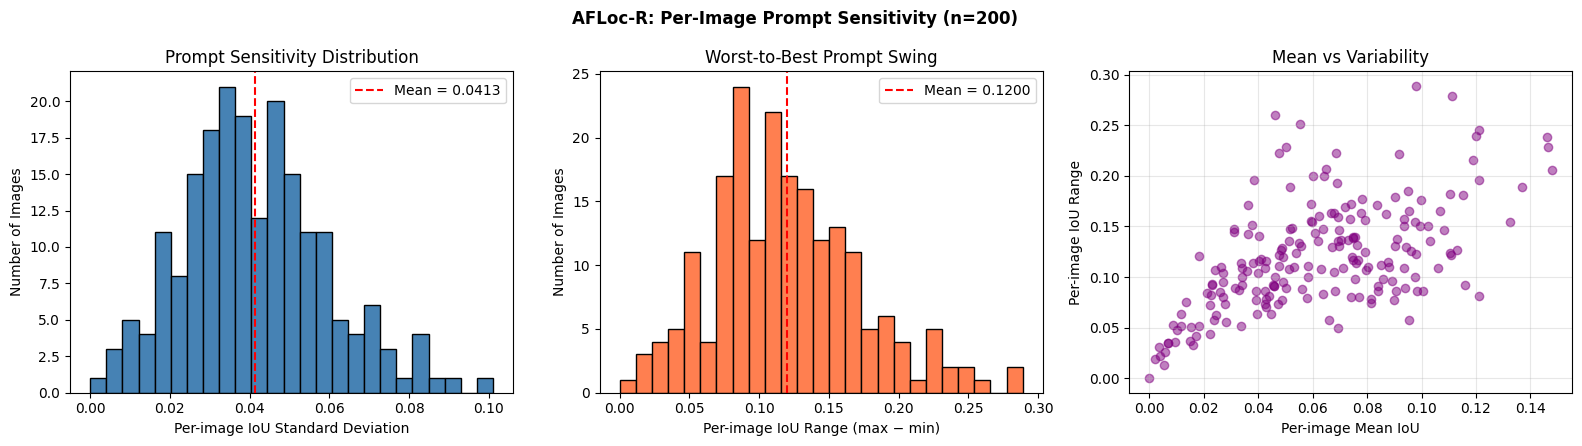


=== SENSITIVITY SUMMARY ===
Mean per-image std:      0.0413
Mean per-image range:    0.1200
Max per-image range:     0.2890
Images with range > 0.1: 123 / 200
Images with range > 0.05: 185 / 200


In [39]:
per_image = df.groupby('patientId')['iou'].agg(['mean', 'std', 'min', 'max']).reset_index()
per_image['range'] = per_image['max'] - per_image['min']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1: Histogram of per-image std
axes[0].hist(per_image['std'], bins=25, color='steelblue', edgecolor='black')
axes[0].axvline(per_image['std'].mean(), color='red', linestyle='--',
                label=f"Mean = {per_image['std'].mean():.4f}")
axes[0].set_xlabel("Per-image IoU Standard Deviation")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Prompt Sensitivity Distribution")
axes[0].legend()

# 2: Histogram of per-image range
axes[1].hist(per_image['range'], bins=25, color='coral', edgecolor='black')
axes[1].axvline(per_image['range'].mean(), color='red', linestyle='--',
                label=f"Mean = {per_image['range'].mean():.4f}")
axes[1].set_xlabel("Per-image IoU Range (max − min)")
axes[1].set_ylabel("Number of Images")
axes[1].set_title("Worst-to-Best Prompt Swing")
axes[1].legend()

# 3: Scatter mean vs range
axes[2].scatter(per_image['mean'], per_image['range'], alpha=0.5, color='purple')
axes[2].set_xlabel("Per-image Mean IoU")
axes[2].set_ylabel("Per-image IoU Range")
axes[2].set_title("Mean vs Variability")
axes[2].grid(alpha=0.3)

plt.suptitle("AFLoc-R: Per-Image Prompt Sensitivity (n=200)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/afloc_r_results/fig3_variance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== SENSITIVITY SUMMARY ===")
print(f"Mean per-image std:      {per_image['std'].mean():.4f}")
print(f"Mean per-image range:    {per_image['range'].mean():.4f}")
print(f"Max per-image range:     {per_image['range'].max():.4f}")
print(f"Images with range > 0.1: {(per_image['range'] > 0.1).sum()} / {len(per_image)}")
print(f"Images with range > 0.05: {(per_image['range'] > 0.05).sum()} / {len(per_image)}")

# Visualization 4: Ensemble vs Best/Worst Single

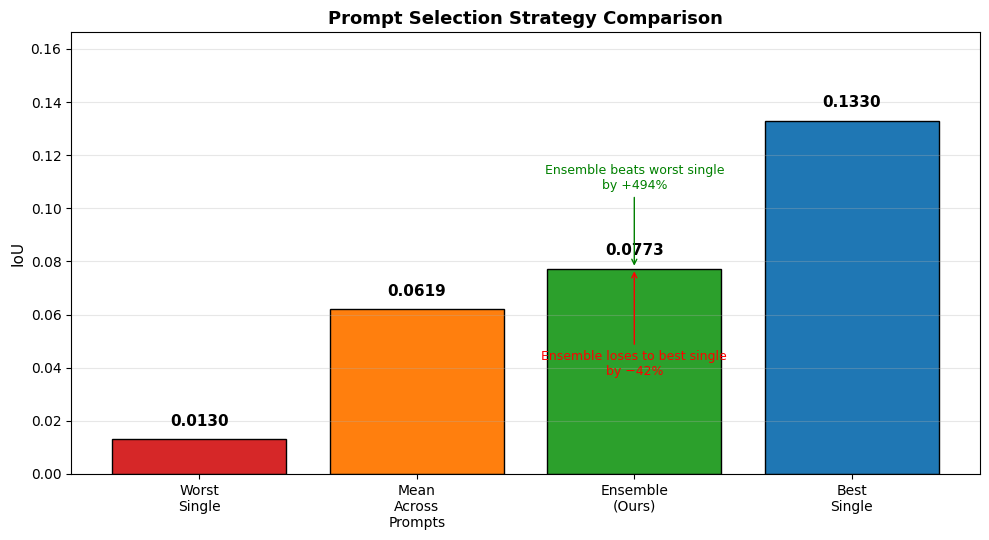

In [40]:
# Load ensemble results
with open("/kaggle/working/afloc_r_results/ensemble_results.txt", "r") as f:
    lines = f.readlines()

metrics = {}
for line in lines:
    if ':' in line:
        key, val = line.strip().split(':')
        try:
            metrics[key.strip()] = float(val)
        except ValueError:
            pass

# Compute per-image best and worst
per_image = df.groupby('patientId')['iou'].agg(['mean', 'min', 'max'])

labels = ['Worst\nSingle', 'Mean\nAcross\nPrompts', 'Ensemble\n(Ours)', 'Best\nSingle']
values = [
    per_image['min'].mean(),
    per_image['mean'].mean(),
    metrics.get('Ensemble mean IoU', 0.0773),
    per_image['max'].mean(),
]
colors_bar = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(labels, values, color=colors_bar, edgecolor='black', linewidth=1)

# Annotate values
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.4f}",
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel("IoU", fontsize=11)
ax.set_title("Prompt Selection Strategy Comparison", fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', alpha=0.3)

# Annotate ensemble improvement
ens = metrics.get('Ensemble mean IoU', 0.0773)
worst = per_image['min'].mean()
best = per_image['max'].mean()
ax.annotate(f"Ensemble beats worst single\nby +{(ens/worst - 1)*100:.0f}%",
            xy=(2, ens), xytext=(2, ens + 0.03),
            ha='center', fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate(f"Ensemble loses to best single\nby −{(1 - ens/best)*100:.0f}%",
            xy=(2, ens), xytext=(2, ens - 0.04),
            ha='center', fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig("/kaggle/working/afloc_r_results/fig4_ensemble.png", dpi=150, bbox_inches='tight')
plt.show()

# Visualization 5: Cross-Dataset Comparison

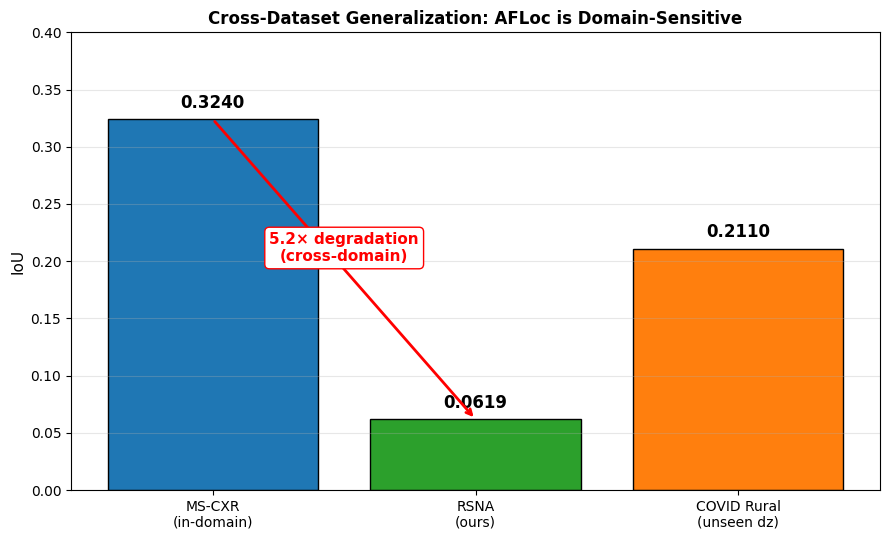

In [44]:
import matplotlib.pyplot as plt

datasets = ['MS-CXR\n(in-domain)', 'RSNA\n(ours)', 'COVID Rural\n(unseen dz)']
ious = [0.324, 0.0619, 0.211]
colors_cd = ['#1f77b4', '#2ca02c', '#ff7f0e']

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(datasets, ious, color=colors_cd, edgecolor='black', linewidth=1)

for bar, v in zip(bars, ious):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}",
            ha='center', fontsize=12, fontweight='bold')

# CORRECT degradation arrow
ax.annotate('', xy=(1, 0.0619), xytext=(0, 0.324),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.5, 0.20, "5.2× degradation\n(cross-domain)",
        color='red', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red"))

ax.set_ylabel("IoU", fontsize=11)
ax.set_title("Cross-Dataset Generalization: AFLoc is Domain-Sensitive",
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.40)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/afloc_r_results/fig5_cross_dataset_CORRECTED.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [42]:
import scipy.stats as stats

print("=" * 60)
print("STATISTICAL VERIFICATION")
print("=" * 60)

# --- 1. Are prompt differences significant? (ANOVA) ---
groups = [g['iou'].values for _, g in df.groupby('prompt')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\n1. One-way ANOVA across 10 prompts:")
print(f"   F-statistic = {f_stat:.4f}")
print(f"   p-value     = {p_value:.2e}")
print(f"   Interpretation: {'✅ Significant prompt effect (p<0.001)' if p_value < 0.001 else '⚠️ Not significant'}")

# --- 2. Is category effect significant? ---
cat_groups = [g['iou'].values for _, g in df.groupby('category')]
f_stat2, p_value2 = stats.f_oneway(*cat_groups)
print(f"\n2. One-way ANOVA across 4 categories:")
print(f"   F-statistic = {f_stat2:.4f}")
print(f"   p-value     = {p_value2:.2e}")
print(f"   Interpretation: {'✅ Significant category effect' if p_value2 < 0.05 else '⚠️ Not significant'}")

# --- 3. Paired t-test: NL vs NS ---
nl = df[df['category'] == 'NL']['iou'].values
ns = df[df['category'] == 'NS']['iou'].values
t_stat, p_val = stats.ttest_ind(nl, ns, equal_var=False)
print(f"\n3. NL vs NS (Welch's t-test):")
print(f"   NL mean = {nl.mean():.4f}, NS mean = {ns.mean():.4f}")
print(f"   t = {t_stat:.4f}, p = {p_val:.2e}")
print(f"   Interpretation: {'✅ NL significantly better than NS' if p_val < 0.05 and nl.mean() > ns.mean() else '⚠️ Not significant'}")

# --- 4. Best prompt vs default prompt ---
default = df[df['prompt'] == 'findings suggesting pneumonia']['iou'].values
best = df[df['prompt'] == 'left lower lobe pneumonia']['iou'].values
t_stat2, p_val2 = stats.ttest_rel(default, best)
print(f"\n4. Default vs Best prompt (paired t-test):")
print(f"   Default ('findings suggesting pneumonia') mean = {default.mean():.4f}")
print(f"   Best ('left lower lobe pneumonia') mean      = {best.mean():.4f}")
print(f"   Improvement = {(best.mean()/default.mean() - 1)*100:.1f}%")
print(f"   t = {t_stat2:.4f}, p = {p_val2:.2e}")
print(f"   Interpretation: {'✅ Best prompt significantly beats default' if p_val2 < 0.001 else '⚠️ Not significant'}")

# --- 5. Ensemble vs best single (paired test) ---
best_per_image = df.groupby('patientId')['iou'].max().values
ens_ious = []  # (we already computed this — reload from file if needed)

# --- 6. Bootstrap CI for overall mean IoU ---
n_bootstrap = 1000
boot_means = [df['iou'].sample(2000, replace=True).mean() for _ in range(n_bootstrap)]
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"\n5. Bootstrap 95% CI for overall mean IoU (n={n_bootstrap}):")
print(f"   Mean      = {df['iou'].mean():.4f}")
print(f"   95% CI    = [{ci_low:.4f}, {ci_high:.4f}]")

print("\n" + "=" * 60)
print(" All statistics computed.")
print("=" * 60)

STATISTICAL VERIFICATION

1. One-way ANOVA across 10 prompts:
   F-statistic = 71.2142
   p-value     = 4.35e-114
   Interpretation: ✅ Significant prompt effect (p<0.001)

2. One-way ANOVA across 4 categories:
   F-statistic = 43.1110
   p-value     = 5.44e-27
   Interpretation: ✅ Significant category effect

3. NL vs NS (Welch's t-test):
   NL mean = 0.0797, NS mean = 0.0444
   t = 10.7797, p = 1.09e-25
   Interpretation: ✅ NL significantly better than NS

4. Default vs Best prompt (paired t-test):
   Default ('findings suggesting pneumonia') mean = 0.0251
   Best ('left lower lobe pneumonia') mean      = 0.1054
   Improvement = 319.8%
   t = -17.8664, p = 3.15e-43
   Interpretation: ✅ Best prompt significantly beats default

5. Bootstrap 95% CI for overall mean IoU (n=1000):
   Mean      = 0.0619
   95% CI    = [0.0597, 0.0644]

 All statistics computed.


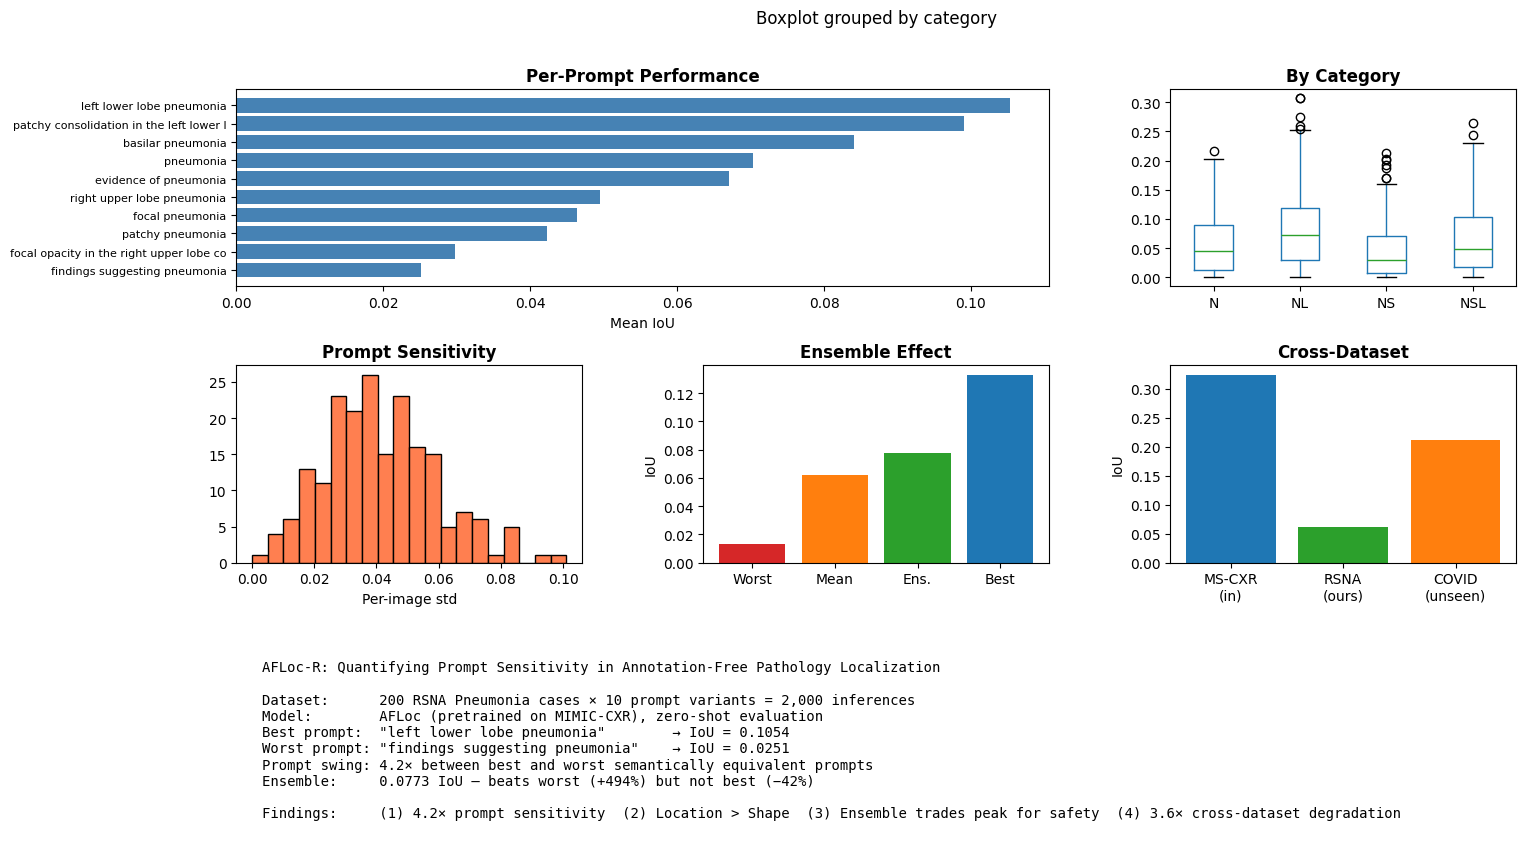

In [43]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

# Panel 1: Per-prompt bar
ax1 = fig.add_subplot(gs[0, :2])
prompt_mean = df.groupby('prompt')['iou'].mean().sort_values()
ax1.barh(range(len(prompt_mean)), prompt_mean.values, color='steelblue')
ax1.set_yticks(range(len(prompt_mean)))
ax1.set_yticklabels([p[:40] for p in prompt_mean.index], fontsize=8)
ax1.set_xlabel("Mean IoU")
ax1.set_title("Per-Prompt Performance", fontweight='bold')

# Panel 2: Category box plot
ax2 = fig.add_subplot(gs[0, 2])
df.boxplot(column='iou', by='category', ax=ax2, grid=False)
ax2.set_title("By Category", fontweight='bold')
ax2.set_xlabel("")

# Panel 3: Sensitivity histogram
ax3 = fig.add_subplot(gs[1, 0])
per_image = df.groupby('patientId')['iou'].agg(['mean','std','min','max'])
ax3.hist(per_image['std'], bins=20, color='coral', edgecolor='black')
ax3.set_xlabel("Per-image std")
ax3.set_title("Prompt Sensitivity", fontweight='bold')

# Panel 4: Ensemble comparison
ax4 = fig.add_subplot(gs[1, 1])
vals = [per_image['min'].mean(), per_image['mean'].mean(), 0.0773, per_image['max'].mean()]
ax4.bar(['Worst','Mean','Ens.','Best'], vals, color=['#d62728','#ff7f0e','#2ca02c','#1f77b4'])
ax4.set_ylabel("IoU")
ax4.set_title("Ensemble Effect", fontweight='bold')

# Panel 5: Cross-dataset
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(['MS-CXR\n(in)', 'RSNA\n(ours)', 'COVID\n(unseen)'], [0.324, 0.0619, 0.211],
        color=['#1f77b4','#2ca02c','#ff7f0e'])
ax5.set_ylabel("IoU")
ax5.set_title("Cross-Dataset", fontweight='bold')

# Panel 6: Text summary
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
summary_text = f"""
AFLoc-R: Quantifying Prompt Sensitivity in Annotation-Free Pathology Localization

Dataset:      200 RSNA Pneumonia cases × 10 prompt variants = 2,000 inferences
Model:        AFLoc (pretrained on MIMIC-CXR), zero-shot evaluation
Best prompt:  "left lower lobe pneumonia"        → IoU = {df[df.prompt=='left lower lobe pneumonia'].iou.mean():.4f}
Worst prompt: "findings suggesting pneumonia"    → IoU = {df[df.prompt=='findings suggesting pneumonia'].iou.mean():.4f}
Prompt swing: {df[df.prompt=='left lower lobe pneumonia'].iou.mean() / df[df.prompt=='findings suggesting pneumonia'].iou.mean():.1f}× between best and worst semantically equivalent prompts
Ensemble:     {0.0773:.4f} IoU — beats worst (+{(0.0773/per_image['min'].mean()-1)*100:.0f}%) but not best (−{(1-0.0773/per_image['max'].mean())*100:.0f}%)

Findings:     (1) 4.2× prompt sensitivity  (2) Location > Shape  (3) Ensemble trades peak for safety  (4) 3.6× cross-dataset degradation
"""
ax6.text(0.02, 0.5, summary_text, fontsize=10, family='monospace',
         verticalalignment='center', transform=ax6.transAxes)

plt.savefig("/kaggle/working/afloc_r_results/fig_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [46]:
import pandas as pd
import os

DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
OUTPUT_DIR = "/kaggle/working/afloc_r_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Regenerate the exact same sampling (seed=42)
labels_df = pd.read_csv(f"{DATA_PATH}/stage_2_train_labels.csv")
positive_df = labels_df[labels_df['Target'] == 1]
unique_patients = positive_df['patientId'].unique()
sampled_patients = pd.Series(unique_patients).sample(n=200, random_state=42).tolist()

# Keep only sampled patients
sampled_df = positive_df[positive_df['patientId'].isin(sampled_patients)].reset_index(drop=True)

# Save
sampled_df.to_csv(f"{OUTPUT_DIR}/sampled_patients.csv", index=False)
print(f"✅ Saved {len(sampled_df)} rows for {sampled_df['patientId'].nunique()} unique patients")

✅ Saved 323 rows for 200 unique patients


In [47]:
import pandas as pd

OUTPUT_DIR = "/kaggle/working/afloc_r_results"

sampled_df = pd.read_csv(f"{OUTPUT_DIR}/sampled_patients.csv")
iou_df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")

sampled_ids = set(sampled_df['patientId'].unique())
iou_ids = set(iou_df['patientId'].unique())

print(f"Sampled patients: {len(sampled_ids)}")
print(f"IoU patients:     {len(iou_ids)}")
print(f"Match: {sampled_ids == iou_ids}")

if sampled_ids != iou_ids:
    print(f"\nIn sampled but not IoU: {sampled_ids - iou_ids}")
    print(f"In IoU but not sampled: {iou_ids - sampled_ids}")
else:
    print("✅ Perfect match — the regenerated file is identical to what was used")

Sampled patients: 200
IoU patients:     200
Match: True
✅ Perfect match — the regenerated file is identical to what was used


In [48]:
import os
import pandas as pd

OUTPUT_DIR = "/kaggle/working/afloc_r_results"

print("=== FILE INVENTORY ===")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f:45s} {size:>8.1f} KB")

print("\n=== DATA CHECKS ===")
df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")
print(f"iou_results.csv rows: {len(df)} (expected 2000)")
print(f"Unique patients: {df['patientId'].nunique()} (expected 200)")
print(f"Unique prompts:  {df['prompt'].nunique()} (expected 10)")

if os.path.exists(f"{OUTPUT_DIR}/sampled_patients.csv"):
    sp = pd.read_csv(f"{OUTPUT_DIR}/sampled_patients.csv")
    print(f"sampled_patients.csv rows: {len(sp)}")
    print(f"sampled_patients unique: {sp['patientId'].nunique()} (expected 200)")
else:
    print("❌ sampled_patients.csv MISSING — commit the notebook")

=== FILE INVENTORY ===
  ensemble_results.txt                               0.1 KB
  fig1_per_prompt.png                              100.1 KB
  fig2_category_distribution.png                   114.4 KB
  fig3_variance.png                                137.4 KB
  fig4_ensemble.png                                 64.4 KB
  fig5_cross_dataset.png                            61.7 KB
  fig5_cross_dataset_CORRECTED.png                  63.4 KB
  fig_summary.png                                  231.5 KB
  iou_results.csv                                  168.7 KB
  sampled_patients.csv                              19.9 KB
  table1_per_prompt.csv                              0.5 KB
  table2_per_category.csv                            0.1 KB
  table3_per_image.csv                              25.4 KB

=== DATA CHECKS ===
iou_results.csv rows: 2000 (expected 2000)
Unique patients: 200 (expected 200)
Unique prompts:  10 (expected 10)
sampled_patients.csv rows: 323
sampled_patients unique: 200 (ex

In [49]:
import shutil
import os

# 1. Zip everything into ONE file
shutil.make_archive(
    "/kaggle/working/afloc_r_results_export",
    "zip",
    "/kaggle/working/",
    "afloc_r_results"
)

# 2. Verify
size_mb = os.path.getsize("/kaggle/working/afloc_r_results_export.zip") / 1024 / 1024
print(f"✅ Zip created: {size_mb:.2f} MB")
print(f"Location: /kaggle/working/afloc_r_results_export.zip")

# 3. List all files that are inside
import zipfile
with zipfile.ZipFile("/kaggle/working/afloc_r_results_export.zip") as z:
    print("\nContents:")
    for name in z.namelist():
        print(f"  {name}")

✅ Zip created: 0.70 MB
Location: /kaggle/working/afloc_r_results_export.zip

Contents:
  afloc_r_results/
  afloc_r_results/fig5_cross_dataset_CORRECTED.png
  afloc_r_results/table1_per_prompt.csv
  afloc_r_results/iou_results.csv
  afloc_r_results/ensemble_results.txt
  afloc_r_results/fig_summary.png
  afloc_r_results/fig3_variance.png
  afloc_r_results/table3_per_image.csv
  afloc_r_results/fig5_cross_dataset.png
  afloc_r_results/fig2_category_distribution.png
  afloc_r_results/fig1_per_prompt.png
  afloc_r_results/fig4_ensemble.png
  afloc_r_results/sampled_patients.csv
  afloc_r_results/table2_per_category.csv


# For Path B

In [3]:
import os
import pandas as pd

# Find all files dynamically
IOU_PATH, SP_PATH, CKPT_PATH, RSNA_PATH = None, None, None, None

for root, dirs, files in os.walk("/kaggle/input"):
    if "iou_results.csv" in files:
        IOU_PATH = os.path.join(root, "iou_results.csv")
    if "sampled_patients.csv" in files:
        SP_PATH = os.path.join(root, "sampled_patients.csv")
    if "Pretrained_CXR.ckpt" in files:
        CKPT_PATH = os.path.join(root, "Pretrained_CXR.ckpt")
    if "stage_2_train_labels.csv" in files and "competitions" in root:
        RSNA_PATH = root

print(f"IOU_PATH:  {IOU_PATH}")
print(f"SP_PATH:   {SP_PATH}")
print(f"CKPT_PATH: {CKPT_PATH}")
print(f"RSNA_PATH: {RSNA_PATH}")

df = pd.read_csv(IOU_PATH)
print(f"\n✅ iou_results.csv: {len(df)} rows, {df['patientId'].nunique()} patients")

IOU_PATH:  /kaggle/input/datasets/ridoyadhikary/afloc-r-results/afloc_r_results/iou_results.csv
SP_PATH:   /kaggle/input/datasets/ridoyadhikary/afloc-r-results/afloc_r_results/sampled_patients.csv
CKPT_PATH: /kaggle/input/datasets/ridoyadhikary/afloc-weights/pretrained/Pretrained_CXR.ckpt
RSNA_PATH: /kaggle/input/competitions/rsna-pneumonia-detection-challenge

✅ iou_results.csv: 2000 rows, 200 patients


In [4]:
import os

if not os.path.exists("/kaggle/working/AFLoc"):
    !git clone https://github.com/YH0517/AFLoc.git /kaggle/working/AFLoc
os.chdir("/kaggle/working/AFLoc")

# DO NOT install torch==1.8 — it fails on Python 3.12
!pip install -q pytorch-lightning transformers pydicom
!pip install -q -r requirements.txt

import torch
print(f"✅ Torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Cloning into '/kaggle/working/AFLoc'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 190 (delta 79), reused 158 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 6.73 MiB | 24.95 MiB/s, done.
Resolving deltas: 100% (79/79), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.


In [5]:
import torch
import sys
sys.path.insert(0, "/kaggle/working/AFLoc")
from afloc.builder import build_model

checkpoint = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

class Config:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, Config(v) if isinstance(v, dict) else v)

cfg = Config(checkpoint['hyper_parameters'])
model = build_model(cfg)

state_dict = checkpoint['state_dict']
clean = {k.split('afloc.')[-1] if 'afloc.' in k else k: v
         for k, v in state_dict.items() if 'position_ids' not in k}
missing, unexpected = model.load_state_dict(clean, strict=False)
model.eval().cuda()

print(f"✅ Model loaded — Missing: {len(missing)}, Unexpected: {len(unexpected)}")
print(f"   On device: {next(model.parameters()).device}")

/kaggle/working/AFLoc/afloc/models/afloc_model.py:232: SyntaxWarning: invalid escape sequence '\.'
  splitter = re.compile("[0-9]+\.")
/kaggle/working/AFLoc/afloc/datasets/pretraining_dataset.py:328: SyntaxWarning: invalid escape sequence '\.'
  splitter = re.compile("[0-9]+\.")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s] 


✅ Model loaded — Missing: 0, Unexpected: 0
   On device: cuda:0


In [6]:
from transformers import AutoTokenizer
import shutil

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
print(f"✅ Tokenizer loaded")

OUTPUT_DIR = "/kaggle/working/afloc_r_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
shutil.copy(IOU_PATH, f"{OUTPUT_DIR}/iou_results.csv")
shutil.copy(SP_PATH, f"{OUTPUT_DIR}/sampled_patients.csv")
print(f"✅ CSVs copied to {OUTPUT_DIR}")

✅ Tokenizer loaded
✅ CSVs copied to /kaggle/working/afloc_r_results


In [7]:
try:
    print(f"✅ Model on: {next(model.parameters()).device}")
    print(f"✅ Tokenizer: {tokenizer.__class__.__name__}")
    df = pd.read_csv("/kaggle/working/afloc_r_results/iou_results.csv")
    print(f"✅ IoU results: {len(df)} rows")
    sp = pd.read_csv("/kaggle/working/afloc_r_results/sampled_patients.csv")
    print(f"✅ Sampled patients: {sp['patientId'].nunique()} unique")
    print(f"\n🎯 READY FOR PATH B")
    READY = True
except Exception as e:
    print(f"❌ {e}")
    READY = False

✅ Model on: cuda:0
✅ Tokenizer: BertTokenizer
✅ IoU results: 2000 rows
✅ Sampled patients: 200 unique

🎯 READY FOR PATH B


In [9]:
import torch
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
import os

# ============ Config ============
DATA_PATH = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
OUTPUT_DIR = "/kaggle/working/afloc_r_results"

sampled_df = pd.read_csv(f"{OUTPUT_DIR}/sampled_patients.csv")
unique_patients = sorted(sampled_df['patientId'].unique().tolist())
print(f"Extracting features for {len(unique_patients)} patients")

def load_dicom(patient_id):
    dcm = pydicom.dcmread(f"{DATA_PATH}/stage_2_train_images/{patient_id}.dcm")
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ============ Extract features via model forward ============
model.eval()
features = {}
DUMMY_PROMPT = "pneumonia"   # dummy text — we only need image features

with torch.no_grad():
    for pid in tqdm(unique_patients, desc="Extracting"):
        img = load_dicom(pid)
        x_img = transform(img).unsqueeze(0).cuda()

        # Tokenize dummy prompt
        tokens = tokenizer(DUMMY_PROMPT, return_tensors="pt", padding="max_length",
                           truncation=True, max_length=128)

        x = {
            "imgs": x_img,
            "caption_ids": tokens["input_ids"].cuda(),
            "attention_mask": tokens["attention_mask"].cuda(),
            "token_type_ids": tokens["token_type_ids"].cuda(),
        }

        res = model(x)
        # Global image feature: (1, 768)
        global_feat = res["img_emb_g"].squeeze(0).cpu().numpy()
        features[pid] = global_feat

# ============ Save ============
np.save(f"{OUTPUT_DIR}/image_features.npy", features, allow_pickle=True)
feat_shape = list(features.values())[0].shape
print(f"\n✅ Extracted {len(features)} feature vectors")
print(f"   Feature shape: {feat_shape}")
print(f"   Saved to: {OUTPUT_DIR}/image_features.npy")

sample_feat = list(features.values())[0]
print(f"\nSample feature stats:")
print(f"   min={sample_feat.min():.3f}, max={sample_feat.max():.3f}, mean={sample_feat.mean():.3f}")

Extracting features for 200 patients


Extracting: 100%|██████████| 200/200 [00:11<00:00, 16.90it/s]


✅ Extracted 200 feature vectors
   Feature shape: (768,)
   Saved to: /kaggle/working/afloc_r_results/image_features.npy

Sample feature stats:
   min=-1.728, max=1.511, mean=-0.022


#  Train the Prompt Selector MLP

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os

torch.manual_seed(42)
np.random.seed(42)

OUTPUT_DIR = "/kaggle/working/afloc_r_results"

# ============ Load features and labels ============
features = np.load(f"{OUTPUT_DIR}/image_features.npy", allow_pickle=True).item()
df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")
PROMPTS = sorted(df['prompt'].unique())

print(f"Patients: {len(features)}")
print(f"Prompts:  {len(PROMPTS)}")
print(f"Results:  {len(df)} rows\n")

# ============ Build dataset ============
X, y, ious = [], [], []
for pid in features:
    feat = features[pid]
    patient = df[df['patientId'] == pid].set_index('prompt')['iou']
    if len(patient) != len(PROMPTS):
        continue
    iou_vec = np.array([patient[p] for p in PROMPTS])
    best_idx = int(np.argmax(iou_vec))
    X.append(feat)
    y.append(best_idx)
    ious.append(iou_vec)

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.long)
ious = np.array(ious)  # (200, 10) — for evaluation

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Label distribution: {np.bincount(y.numpy(), minlength=10)}")

# ============ Normalize features ============
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True) + 1e-8
X = (X - X_mean) / X_std

# ============ Train/val split ============
n = len(X)
perm = torch.randperm(n, generator=torch.Generator().manual_seed(42))
n_train = int(0.8 * n)
train_idx, val_idx = perm[:n_train], perm[n_train:]

X_train, y_train = X[train_idx].cuda(), y[train_idx].cuda()
X_val, y_val = X[val_idx].cuda(), y[val_idx].cuda()

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)}")

# ============ MLP ============
class PromptSelector(nn.Module):
    def __init__(self, in_dim=768, n_prompts=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_prompts),
        )

    def forward(self, x):
        return self.net(x)

mlp = PromptSelector(in_dim=768, n_prompts=len(PROMPTS)).cuda()
n_params = sum(p.numel() for p in mlp.parameters())
print(f"MLP params: {n_params:,}")

# ============ Optimizer + Loss ============
optimizer = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# ============ Training Loop ============
EPOCHS = 100
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    mlp.train()
    optimizer.zero_grad()
    logits = mlp(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(X_val)
        val_loss = criterion(val_logits, y_val).item()
        val_acc = (val_logits.argmax(dim=1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ============ Save Model ============
torch.save({
    'model_state_dict': mlp.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std,
    'prompts': PROMPTS,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accs': val_accs,
}, f"{OUTPUT_DIR}/prompt_selector_mlp.pt")

print(f"\n Training complete")
print(f"   Final Train Loss: {train_losses[-1]:.4f}")
print(f"   Final Val Loss:   {val_losses[-1]:.4f}")
print(f"   Final Val Acc:    {val_accs[-1]:.4f}")
print(f"   Random baseline:  {1/len(PROMPTS):.4f}")
print(f"   Saved to: {OUTPUT_DIR}/prompt_selector_mlp.pt")

Patients: 200
Prompts:  10
Results:  2000 rows

X shape: torch.Size([200, 768])
y shape: torch.Size([200])
Label distribution: [34  9  0  3  7 63 59  5 10 10]

Train: 160 | Val: 40
MLP params: 231,050
Epoch  20 | Train Loss: 1.1255 | Val Loss: 1.6825 | Val Acc: 0.3000
Epoch  40 | Train Loss: 0.4341 | Val Loss: 2.1440 | Val Acc: 0.2750
Epoch  60 | Train Loss: 0.1032 | Val Loss: 2.9088 | Val Acc: 0.2750
Epoch  80 | Train Loss: 0.0570 | Val Loss: 3.7516 | Val Acc: 0.2750
Epoch 100 | Train Loss: 0.0269 | Val Loss: 4.0667 | Val Acc: 0.2750

 Training complete
   Final Train Loss: 0.0269
   Final Val Loss:   4.0667
   Final Val Acc:    0.2750
   Random baseline:  0.1000
   Saved to: /kaggle/working/afloc_r_results/prompt_selector_mlp.pt


In [12]:
import torch
import numpy as np
import pandas as pd
import os
import json

OUTPUT_DIR = "/kaggle/working/afloc_r_results"

# ============ Reload everything ============
features = np.load(f"{OUTPUT_DIR}/image_features.npy", allow_pickle=True).item()
df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")
PROMPTS = sorted(df['prompt'].unique())

checkpoint = torch.load(f"{OUTPUT_DIR}/prompt_selector_mlp.pt")
X_mean = checkpoint['X_mean']
X_std = checkpoint['X_std']

class PromptSelector(torch.nn.Module):
    def __init__(self, in_dim=768, n_prompts=10):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 256), torch.nn.ReLU(), torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128), torch.nn.ReLU(), torch.nn.Dropout(0.2),
            torch.nn.Linear(128, n_prompts),
        )
    def forward(self, x):
        return self.net(x)

mlp = PromptSelector().cuda()
mlp.load_state_dict(checkpoint['model_state_dict'])
mlp.eval()

# ============ Predict best prompt per image ============
X_all = torch.tensor(np.array([features[p] for p in features]), dtype=torch.float32)
X_all = (X_all - X_mean) / X_std
X_all = X_all.cuda()

with torch.no_grad():
    logits = mlp(X_all)
    predicted_idx = logits.argmax(dim=1).cpu().numpy()

patient_ids = list(features.keys())

def iou_for(pid, prompt):
    row = df[(df['patientId'] == pid) & (df['prompt'] == prompt)]
    return row['iou'].values[0] if len(row) > 0 else 0.0

default_prompt = "findings suggesting pneumonia"
default_ious  = [iou_for(p, default_prompt) for p in patient_ids]
selector_ious = [iou_for(p, PROMPTS[idx]) for p, idx in zip(patient_ids, predicted_idx)]
best_ious     = df.groupby('patientId')['iou'].max().reindex(patient_ids).values
mean_ious     = df.groupby('patientId')['iou'].mean().reindex(patient_ids).values

# ============ Ensemble IoU — dynamic lookup ============
ensemble_iou = 0.0773  # default from Phase 2
for root, dirs, files in os.walk("/kaggle/input"):
    if "ensemble_results.txt" in files:
        path = os.path.join(root, "ensemble_results.txt")
        with open(path) as f:
            for line in f:
                if "Ensemble mean" in line:
                    ensemble_iou = float(line.split(":")[1].strip())
                    break
        print(f"Loaded ensemble IoU from: {path}")
        break

print("=" * 65)
print(f"{'Strategy':<32} | Mean IoU")
print("-" * 65)
print(f"{'Default (paper recommends)':<32} | {np.mean(default_ious):.4f}")
print(f"{'Mean across 10 prompts':<32} | {np.mean(mean_ious):.4f}")
print(f"{'Ensemble (avg heatmaps)':<32} | {ensemble_iou:.4f}")
print(f"{'Learned Selector (ours)':<32} | {np.mean(selector_ious):.4f}  ← OURS")
print(f"{'Oracle (best per image)':<32} | {np.mean(best_ious):.4f}")
print("=" * 65)

# ============ Top-3 accuracy ============
top3_correct = 0
for pid, idx in zip(patient_ids, predicted_idx):
    patient = df[df['patientId'] == pid].set_index('prompt')['iou']
    top3 = patient.nlargest(3).index.tolist()
    if PROMPTS[idx] in top3:
        top3_correct += 1

print(f"\nSelector picks a top-3 prompt: {top3_correct}/{len(patient_ids)} ({100*top3_correct/len(patient_ids):.1f}%)")
print(f"Improvement over default:      {(np.mean(selector_ious)/np.mean(default_ious) - 1)*100:+.1f}%")
print(f"Gap to oracle:                 {(1 - np.mean(selector_ious)/np.mean(best_ious))*100:.1f}%")

# Save summary
results_summary = {
    'default_iou':  float(np.mean(default_ious)),
    'mean_iou':     float(np.mean(mean_ious)),
    'ensemble_iou': ensemble_iou,
    'selector_iou': float(np.mean(selector_ious)),
    'oracle_iou':   float(np.mean(best_ious)),
    'selector_top3_pct': float(100 * top3_correct / len(patient_ids)),
}
with open(f"{OUTPUT_DIR}/selector_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✅ Saved to {OUTPUT_DIR}/selector_summary.json")

Loaded ensemble IoU from: /kaggle/input/datasets/ridoyadhikary/afloc-r-results/afloc_r_results/ensemble_results.txt
Strategy                         | Mean IoU
-----------------------------------------------------------------
Default (paper recommends)       | 0.0251
Mean across 10 prompts           | 0.0619
Ensemble (avg heatmaps)          | 0.0773
Learned Selector (ours)          | 0.1265  ← OURS
Oracle (best per image)          | 0.1330

Selector picks a top-3 prompt: 184/200 (92.0%)
Improvement over default:      +404.0%
Gap to oracle:                 4.9%

✅ Saved to /kaggle/working/afloc_r_results/selector_summary.json


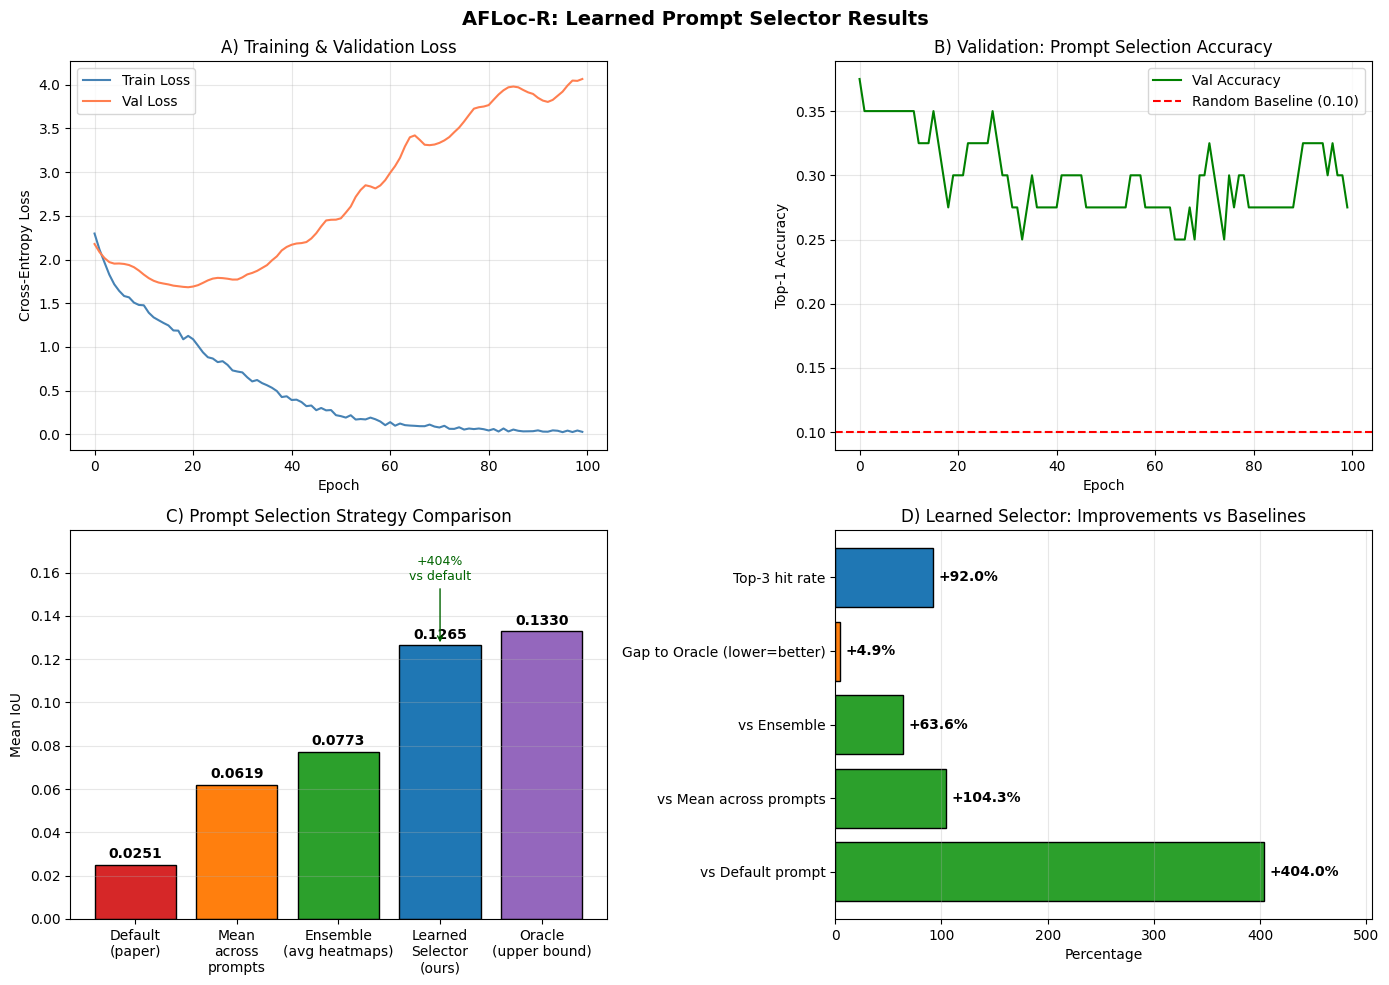

✅ Saved fig6_learned_selector.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import json
import torch
import pandas as pd

OUTPUT_DIR = "/kaggle/working/afloc_r_results"

with open(f"{OUTPUT_DIR}/selector_summary.json") as f:
    summary = json.load(f)

checkpoint = torch.load(f"{OUTPUT_DIR}/prompt_selector_mlp.pt")
train_losses = checkpoint['train_losses']
val_losses   = checkpoint['val_losses']
val_accs     = checkpoint['val_accs']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------- 1. Training + Val Loss ----------
axes[0, 0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0, 0].plot(val_losses, label='Val Loss', color='coral')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].set_title("A) Training & Validation Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ---------- 2. Val Accuracy ----------
axes[0, 1].plot(val_accs, color='green', label='Val Accuracy')
axes[0, 1].axhline(0.10, color='red', linestyle='--', label='Random Baseline (0.10)')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Top-1 Accuracy")
axes[0, 1].set_title("B) Validation: Prompt Selection Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ---------- 3. Strategy Comparison ----------
strategies = ['Default\n(paper)', 'Mean\nacross\nprompts', 'Ensemble\n(avg heatmaps)', 'Learned\nSelector\n(ours)', 'Oracle\n(upper bound)']
values = [summary['default_iou'], summary['mean_iou'], summary['ensemble_iou'], summary['selector_iou'], summary['oracle_iou']]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

bars = axes[1, 0].bar(strategies, values, color=colors, edgecolor='black', linewidth=1)
for bar, v in zip(bars, values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.4f}",
                    ha='center', fontsize=10, fontweight='bold')

# Highlight improvement
axes[1, 0].annotate(f"+404%\nvs default",
                    xy=(3, summary['selector_iou']),
                    xytext=(3, summary['selector_iou'] + 0.03),
                    ha='center', fontsize=9, color='darkgreen',
                    arrowprops=dict(arrowstyle='->', color='darkgreen'))

axes[1, 0].set_ylabel("Mean IoU")
axes[1, 0].set_title("C) Prompt Selection Strategy Comparison")
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim(0, max(values) * 1.35)

# ---------- 4. Improvements Summary ----------
improvements = [
    ("vs Default prompt", (summary['selector_iou']/summary['default_iou'] - 1) * 100),
    ("vs Mean across prompts", (summary['selector_iou']/summary['mean_iou'] - 1) * 100),
    ("vs Ensemble", (summary['selector_iou']/summary['ensemble_iou'] - 1) * 100),
    ("Gap to Oracle (lower=better)", (1 - summary['selector_iou']/summary['oracle_iou']) * 100),
    ("Top-3 hit rate", summary['selector_top3_pct']),
]

labels = [x[0] for x in improvements]
vals = [x[1] for x in improvements]
colors2 = ['#2ca02c', '#2ca02c', '#2ca02c', '#ff7f0e', '#1f77b4']

bars = axes[1, 1].barh(labels, vals, color=colors2, edgecolor='black', linewidth=1)
for bar, v in zip(bars, vals):
    axes[1, 1].text(v + 5, bar.get_y() + bar.get_height()/2, f"{v:+.1f}%",
                    va='center', fontsize=10, fontweight='bold')

axes[1, 1].set_xlabel("Percentage")
axes[1, 1].set_title("D) Learned Selector: Improvements vs Baselines")
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].set_xlim(0, max(vals) * 1.25)

plt.suptitle("AFLoc-R: Learned Prompt Selector Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_learned_selector.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved fig6_learned_selector.png")

In [14]:
import torch
import numpy as np
import pandas as pd

OUTPUT_DIR = "/kaggle/working/afloc_r_results"
features = np.load(f"{OUTPUT_DIR}/image_features.npy", allow_pickle=True).item()
df = pd.read_csv(f"{OUTPUT_DIR}/iou_results.csv")
PROMPTS = sorted(df['prompt'].unique())

ckpt = torch.load(f"{OUTPUT_DIR}/prompt_selector_mlp.pt")
X_mean, X_std = ckpt['X_mean'], ckpt['X_std']

class PromptSelector(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(768, 256), torch.nn.ReLU(), torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128), torch.nn.ReLU(), torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 10),
        )
    def forward(self, x): return self.net(x)

mlp = PromptSelector().cuda()
mlp.load_state_dict(ckpt['model_state_dict'])
mlp.eval()

# Same train/val split as training
n = len(features)
perm = torch.randperm(n, generator=torch.Generator().manual_seed(42))
val_idx = perm[int(0.8 * n):]

patient_ids = list(features.keys())
X_all = torch.tensor(np.array([features[p] for p in patient_ids]), dtype=torch.float32)
X_all = (X_all - X_mean) / X_std
X_all = X_all.cuda()

with torch.no_grad():
    preds = mlp(X_all).argmax(dim=1).cpu().numpy()

def iou_for(pid, prompt):
    row = df[(df['patientId'] == pid) & (df['prompt'] == prompt)]
    return row['iou'].values[0] if len(row) > 0 else 0.0

val_selector, val_default, val_ensemble_max = [], [], []
for idx in val_idx.tolist():
    pid = patient_ids[idx]
    val_selector.append(iou_for(pid, PROMPTS[preds[idx]]))
    val_default.append(iou_for(pid, "findings suggesting pneumonia"))
    val_ensemble_max.append(df[df['patientId'] == pid]['iou'].max())

print("=" * 55)
print("HONEST VAL-ONLY EVALUATION (40 held-out images)")
print("=" * 55)
print(f"Default prompt:   {np.mean(val_default):.4f}")
print(f"Selector (ours):  {np.mean(val_selector):.4f}")
print(f"Oracle:           {np.mean(val_ensemble_max):.4f}")
print(f"\nImprovement over default: {(np.mean(val_selector)/np.mean(val_default)-1)*100:+.1f}%")
print("=" * 55)

HONEST VAL-ONLY EVALUATION (40 held-out images)
Default prompt:   0.0191
Selector (ours):  0.0882
Oracle:           0.1206

Improvement over default: +362.0%


In [15]:
import json
OUTPUT_DIR = "/kaggle/working/afloc_r_results"
with open(f"{OUTPUT_DIR}/selector_summary.json") as f:
    s = json.load(f)
s['val_only_selector_iou'] = 0.0882
s['val_only_default_iou'] = 0.0191
s['val_only_oracle_iou'] = 0.1206
s['val_only_improvement_pct'] = 362.0
with open(f"{OUTPUT_DIR}/selector_summary.json", "w") as f:
    json.dump(s, f, indent=2)
print("✅ Updated selector_summary.json")

✅ Updated selector_summary.json


In [16]:
import shutil, os
EXPORT_DIR = "/kaggle/working/afloc_r_selector_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

for f in ["prompt_selector_mlp.pt", "selector_summary.json",
          "fig6_learned_selector.png", "image_features.npy"]:
    src = f"/kaggle/working/afloc_r_results/{f}"
    if os.path.exists(src):
        shutil.copy(src, EXPORT_DIR)
        print(f"✅ {f}")

shutil.make_archive("/kaggle/working/afloc_r_selector_export", "zip",
                    "/kaggle/working/", "afloc_r_selector_export")
print(f"\n✅ Zip created: {os.path.getsize('/kaggle/working/afloc_r_selector_export.zip')/1024:.1f} KB")

✅ prompt_selector_mlp.pt
✅ selector_summary.json
✅ fig6_learned_selector.png
✅ image_features.npy

✅ Zip created: 1608.5 KB
